# Машинное обучение, ВМК МГУ

# Практическое задание 1. Методы оптимизации в машинном обучении

## Общая информация
Дата выдачи: 21.02.2026

Мягкий дедлайн: 08.03.2026 05:00 MSK

Жёсткий дедлайн: 15.03.2026 05:00 MSK

## Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). **Максимальная оценка за работу  — 10 баллов + 9.2 бонусов.**

Сдавать задание после указанного жёсткого срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-optimization-Username.ipynb

<p style="color:#de3815;font-size:25px;">
Напоминание об оформлении и выполнении ноутбука
</p>

* Все строчки должны быть выполнены. Нужно, чтобы output команды можно было увидеть, не запуская ячейки (кроме редких случаев, когда необходимо намеренно скрыть ненужный output, про такие случаи желательно писать пояснения в тексте). **В противном случае -1 балл**
* При оформлении ДЗ нужно пользоваться данным файлом в качестве шаблона. Не нужно удалять и видоизменять написанный код и текст, если явно не указана такая возможность. **В противном случае -1 балл**
* В anytask обязательно нужно прикреплять отдельно файл с расширением ipynb (не в архиве, а именно отдельно). Если необходимо отправить еще какие-то файлы, то вынесите их в отдельный архив (если файлов много) и пришлите. **В противном случае -0.5 балла**
---
* Пишите, пожалуйста, выводы и ответы на вопросы в текстовых ячейках/при помощи print в коде. При их отсутствии мы не можем понять, сделали ли вы задание и понимаете, что происходит, и **поэтому будем снижать баллы**
* Если алгоритм не сказано реализовывать явно, его всегда можно импортировать из библиотеки.
---
* Про графики. _Штрафы будут применяться к каждому результату команды отображения графика (plt.show() и др. аналогичные). Исключением являются графики, генерируемые функциями каких-либо сторонних библиотек, если их нельзя кастомизировать_

    * должно быть название (plt.title) графика; **В противном случае &ndash; -0.05 балла**
    * на графиках должны быть подписаны оси (plt.xlabel, plt.ylabel); **В противном случае &ndash; -0.025 балла за каждую ось**
    * должны быть подписаны единицы измерения (если это возможно); **В противном случае &ndash; -0.025 балла за каждую ось**
    * все названия должны быть понятны любому человеку, знакомому с терминологией, без заглядывания в код; **В противном случае &ndash; -0.05 балла**
    * подписи тиков на осях не должны сливаться как на одной оси, так и между ними; **В противном случае &ndash; -0.025 балла за каждую ось**
    * если изображено несколько сущностей на одном холсте (например несколько функций), то необходима поясняющая легенда (plt.legend); **В противном случае &ndash; -0.05 балла**
    * все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном); **В противном случае &ndash; -0.05 балла**
    * если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах);
    * графики должны быть не супер-микро и не супер-макро по размерам, так, чтобы можно было увидеть все, что нужно.
    * при необходимости улучшения наглядности графиков, можно пользоваться логарифмической шкалой по осям x/y.
    
    
### А также..

* Для удобства поиска вопросов, на которые от вас просят ответа, мы пометили их знаком **(?)**
* Знак **(!)** означает, что выполнение замечания необходимо для **возможности получения полного балла**
* Даем до +0.3 балла за выдающиеся успехи по субъективному мнению проверяющих. Этот **бонус** не апеллируется

### Часть 1. (1.5 балла) Негладкая оптимизация

В этом разделе мы рассмотрим задачу Lasso регрессии и сравним рассказанные на парах методы: субградиентный метод, ISTA и FISTA. Напомним, что задача выглядит следующим образом:

$$
\min_x \frac{1}{2}\|Ax - y \|^2_2 + \gamma \|x\|_1
$$

Для автоматического вычисления градиентов предлагается использовать jax, вы можете считать их руками или через torch, но мы считаем, что знать о существовании этой библиотеки полезно, тем более, что для выполнения задания достаточно знать информации с [этой страницы](https://jax.readthedocs.io/en/latest/notebooks/quickstart.html).

In [ ]:
!pip install jax

   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.8/3.0 MB 1.8 MB/s eta 0:00:02
   -------------- ------------------------- 1.0/3.0 MB 2.1 MB/s eta 0:00:01
   --------------------- ------------------ 1.6/3.0 MB 2.1 MB/s eta 0:00:01
   ---------------------------- ----------- 2.1/3.0 MB 2.1 MB/s eta 0:00:01
   ------------------------------- -------- 2.4/3.0 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 3.0/3.0 MB 2.1 MB/s  0:00:01
   ---------------------------------------- 0.0/60.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/60.5 MB ? eta -:--:--
    --------------------------------------- 0.8/60.5 MB 2.1 MB/s eta 0:00:29
    --------------------------------------- 1.0/60.5 MB 1.9 MB/s eta 0:00:31
   - -------------------------------------- 1.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.3/782.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.4 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


In [ ]:
from comet_ml import Experiment

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import cv2
import tqdm
import jax.numpy as jnp
from jax import grad, jit, vmap
import jax
import sklearn.preprocessing as skprep
from tqdm import tqdm

In [ ]:
%config InlineBackend.figure_formats = ['svg']
sns.set_style('darkgrid')

In [ ]:
%matplotlib inline

Для сравнения методов сгенерируем данные:

In [ ]:
m = 500
n = 2500
np.random.seed(1)
A = np.random.rand(m, n) # матрица
A = skprep.normalize(A, norm="l2", axis=0)
U, S, Vh = np.linalg.svd(A, full_matrices=False)
S[-1] = min(S[-1], S[0] / 100000)
A = U @ (S[:, None] * Vh)
x_true = np.random.randn(n) # решение
x_true[np.random.rand(n) < 0.96] = 0
v = 9e-2 * np.random.randn(m)
y = A.dot(x_true) + v # таргет
gamma = 0.01 * np.linalg.norm(A.T.dot(y), ord=np.inf) # предлагаемый коэффициент регуляризации
x0 = np.random.rand(n) # начальное приближение

Давайте посмотрим на степень разреженности решения

In [ ]:
print(f"Number of nonzeros in x_true is {np.sum(x_true != 0)} out of {x_true.shape[0]}")

Number of nonzeros in x_true is 84 out of 2500


**Задание 1. (0.15 баллов)** реализуйте оракул для Lasso регрессии с использованием jax, также реализуйте отдельно оракул для части с регрессией и для регуляризации, а также их градиентов. Для регуляризации добавьте метод prox, который вычисляет проксимальный оператор в заданной точке.

*Замечание*. Вы можете менять интерфейсы классов так, как считаете нужным, предложенный вариант - один из возможных. Главное, чтобы все работало

In [ ]:
class LassoRegressionOracle:
    '''
    Class for whole Lasso regression oracle
    '''
    def __init__(self, A, y, gamma):
        self.A = A
        self.y = y
        self.gamma = gamma

    def __call__(self, x):
        return (1/2)*jnp.sum((self.A@x - self.y)**2) + self.gamma*jnp.sum(jnp.abs(x))

    def grad(self, x):
        #return grad(self.__call__)(x)
        key = jax.random.PRNGKey(0)
        key, subkey = jax.random.split(key)
        grad_smooth = self.A.T @ (self.A @ x - self.y)
        rand = jax.random.uniform(subkey, shape=x.shape, minval=-1.0,maxval=1.0)
        subgrad_l1 = jnp.where(x > 0, 1.0,jnp.where(x < 0, -1.0, rand))
        return grad_smooth + self.gamma * subgrad_l1

In [ ]:
class BasicRegressionOracle:
    '''
    Class for regression part of lasso regression
    '''
    def __init__(self, A, y):
        self.A = A
        self.y = y

    def __call__(self, x):
        return (1/2)*jnp.sum((self.A@x - self.y)**2)

    def grad(self, x):
        return self.A.T @ (self.A@x - self.y)

In [ ]:
class L1RegularizationOracle:
    '''
    Class for regularization part of lasso regression
    '''
    def __init__(self, gamma):
        self.gamma = gamma

    def __call__(self, x):
        return self.gamma*jnp.sum(jnp.abs(x))

    def prox(self, x, alpha):
        return jnp.sign(x)*jnp.maximum(jnp.abs(x)-alpha*self.gamma, 0)

Выведите значения функционалов в точке x0:

In [ ]:
full_oracle = LassoRegressionOracle(A, y, gamma)
regression_oracle = BasicRegressionOracle(A, y)
regularization_oracle = L1RegularizationOracle(gamma)

assert np.allclose(full_oracle(x0), 581375.6875)
assert np.allclose(regression_oracle(x0), 581222.1875)
assert np.allclose(regularization_oracle(x0), 153.4744415283203)
assert np.allclose(full_oracle.grad(x0).sum(), 2334791.5)
assert np.allclose(regression_oracle.grad(x0).sum(), 2334486.8)
assert np.allclose(regularization_oracle.prox(x0, 1).sum(), 973.6881)

**Задание 2 (0.65 баллов)**. Реализуйте субградиентный метод, ISTA и FISTA.

1) Для субградиентного метода возьмите шаг $\alpha_k=\frac{1}{\sqrt{k + 1}}$. Он является одним из самых популярных выборов для рассматриваемого метода. **Обратите внимание**, что для субградиентного метода результатом является не последняя точка, а точка, в которой наблюдалось минимальное значение функционала

2) Для ISTA/FISTA выберете константный шаг. **Аккуратно следите за согласованием параметра прокса и lr**

3) Параметр, отвечающий за ускорение, возьмите равным $\frac{k}{k+3}$

*Замечание*. Вы можете менять интерфейсы функций так, как считаете нужным, предложенный вариант - один из возможных. Главное, чтобы все работало

In [ ]:
def subgradient_method(oracle, max_iters, x0):
    """
    Функция, реализующая субградиентный метод
    :oracle - оракул
    :max_iters - максимальное количество итераций
    :x0 - начальная точка

    Функция возвращает историю (наименьшее значение функции по итерациям) и итоговую точку
    """
    history = {}
    history_x = {}
    x = x0
    x_result = x0
    best_val = float(oracle(x0))
    for k in range(max_iters):
      alpha_k = 1/jnp.sqrt(k+1)
      x = x - alpha_k * oracle.grad(x)
      val = oracle(x)
      if val < best_val:
          best_val = float(val)
          x_result = x
      history[k] = best_val
      history_x[k] = x_result
    return history, x_result, history_x

In [ ]:
def ISTA(full_oracle, regression_oracle, regularization_oracle, max_iters, x0, step_size):
    """
    Функция, реализующая проксимальный градиентный метод, в данном случае это будет ISTA
    :full_oracle - полный оракул
    :regression_oracle - оракул, содержащий регрессионную часть
    :regularization_oracle - оракул, содержащий регуляризационную
    :max_iters - максимальное количество итераций
    :x0 - начальная точка
    :step_size - размер шага

    Функция возвращает историю (значение функции в полученных в процессе итераций точках) и итоговую точку
    """
    history = {}
    history_x = {}
    x_k = x0
    for k in range(max_iters):
      x_k = x_k - step_size*regression_oracle.grad(x_k)
      x_k = regularization_oracle.prox(x_k, step_size)
      val = full_oracle(x_k)
      history[k] = val
      history_x[k] = x_k
    return history, x_k, history_x

In [ ]:
def FISTA(full_oracle, regression_oracle, regularization_oracle, max_iters, x0, step_size):
    """
    Функция, реализующая ускоренный проксимальный градиентный метод, в данном случае это будет FISTA
    :full_oracle - полный оракул
    :regression_oracle - оракул, содержащий регрессионную часть
    :regularization_oracle - оракул, содержащий регуляризационную
    :max_iters - максимальное количество итераций
    :x0 - начальная точка
    :step_size - размер шага

    Функция возвращает историю (значение функции в полученных в процессе итераций точках) и итоговую точку
    """
    history = {}
    history_x = {}

    x_k = x0
    y_k = x0
    t_k = 1.0

    for k in range(max_iters):
        x_next = y_k - step_size * regression_oracle.grad(y_k)
        x_next = regularization_oracle.prox(x_next, step_size)
        t_next = (1.0 + jnp.sqrt(1.0 + 4.0 * t_k**2)) / 2.0
        y_next = x_next + ((t_k - 1.0) / t_next) * (x_next - x_k)
        x_k, y_k, t_k = x_next, y_next, t_next
        history[k] = full_oracle(x_k)
        history_x[k] = x_k
    return history, x_k, history_x

**Задание 3. (0.3 баллов)** Посмотрите на скорость сходимости (используйте логарифмическую шкалу) ISTA и FISTA при разных размерах шага. Выберите лучший, сделайте выводы. Рассмотрите не менее 5 размеров шагов в диапазоне $10^{-5}...10^{-3}$. **Используйте не менее 30000 итераций**

In [ ]:
steps = jnp.logspace(-5, -3, 5)
iters = 30000
histories = {'ista': {}, 'fista': {}}
with tqdm(total=10) as pbar:
  for step in steps:
    step_f = float(step)
    hist_ista = ISTA(full_oracle, regression_oracle, regularization_oracle, iters, x0, step_f)
    pbar.update(1)
    hist_fista = FISTA(full_oracle, regression_oracle, regularization_oracle, iters, x0, step_f)
    pbar.update(1)
    histories['ista'][step_f] = hist_ista[0]
    histories['fista'][step_f] = hist_fista[0]


100%|███████████████████████████████████████████████████████████████████████████████| 10/10 [1:05:35<00:00, 393.50s/it]


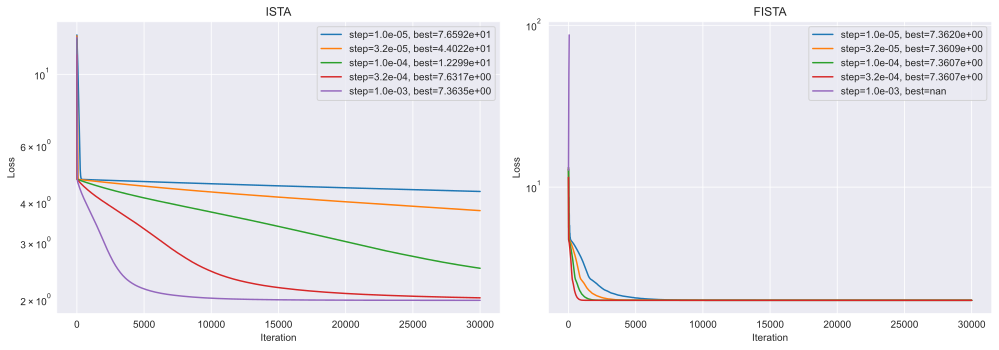

In [ ]:
def history_to_xy(history):
    if isinstance(history, dict):
        it = np.array(sorted(history.keys()))
        vals = np.array([float(history[k]) for k in it])
        return it, vals
    vals = np.asarray(history)
    it = np.arange(vals.size)
    return it, vals


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for step, history in histories['ista'].items():
    it, vals = history_to_xy(history)
    best_val = vals.min()
    vals_log = np.log(vals) #чтобы график более читаемым сделать, делаю log(log(x))
    ax.plot(it, vals_log, label=f"step={step:.1e}, best={best_val:.4e}")

ax.set_title("ISTA")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.grid(True)

ax = axes[1]
for step, history in histories['fista'].items():
    it, vals = history_to_xy(history)
    best_val = vals.min()
    vals_log = np.log(vals)
    ax.plot(it, vals_log, label=f"step={step:.1e}, best={best_val:.4e}")

ax.set_title("FISTA")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

**Выводы:** у обоих методов четко видно, что с ростом шага увеличивается скорость сходимости увеличивается. И если у метода FISTA при всех шагах (кроме 1e-3) метод сошелся, то у ISTA к оптимуму сошлись только вариации с двумя самыми большими шагами. Случай с step=1e-3 у FISTA стоит рассмотреть отдельно, так как при слишком большом шаге (1e-3) FISTA становится неустойчивым и расходится (возникает nan), что связано с превышением допустимого шага.

**Задание 4. (0.4 баллов)** Сравните три метода оптимизации по скорости сходимости, а также по степени разреженности решения (считайте, что число равно нулю, если оно по модулю не превосходит $10^{-2}$). Для этого нарисуйте два графика: первый - зависимость значения функции от номера итерации, а второй - количество ненулевых значений от итерации. Сделайте выводы. **Используйте не менее 30000 итераций**

In [ ]:
iters = 30000
step_ista, step_fista = 1e-3, 3e-4
hist_vals_ista, last_x_ista, hist_x_ista = ISTA(full_oracle, regression_oracle, regularization_oracle, iters, x0, step_ista)
hist_vals_fista, last_x_fista, hist_x_fista = FISTA(full_oracle, regression_oracle, regularization_oracle, iters, x0, step_fista)
hist_vals_subg, best_x_subg, hist_x_subg = subgradient_method(full_oracle, iters, x0)

In [ ]:
def dict_to_arrays(history_dict):
    iters = np.array(sorted(history_dict.keys()))
    values = np.array([float(history_dict[k]) for k in iters])
    return iters, values

def sparsity_from_history(history_x_dict, tol=1e-2):
    iters = np.array(sorted(history_x_dict.keys()))
    counts = []
    for k in iters:
        x = np.asarray(history_x_dict[k])
        count_nonzero = np.sum(np.abs(x) > tol)
        counts.append(count_nonzero)
    return np.array(counts)

In [ ]:
it_ista, vals_ista = dict_to_arrays(hist_vals_ista)
it_fista, vals_fista = dict_to_arrays(hist_vals_fista)
it_subg, vals_subg = dict_to_arrays(hist_vals_subg)

spars_ista = sparsity_from_history(hist_x_ista)
spars_fista = sparsity_from_history(hist_x_fista)
spars_subg = sparsity_from_history(hist_x_subg)

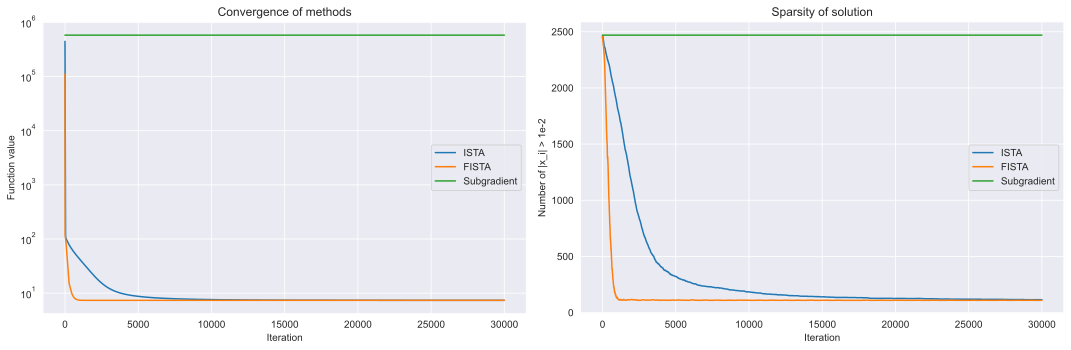

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(it_ista, vals_ista, label="ISTA")
ax.plot(it_fista, vals_fista, label="FISTA")
ax.plot(it_subg, vals_subg, label="Subgradient")

ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Function value")
ax.set_title("Convergence of methods")
ax.legend()
ax.grid(True)


ax = axes[1]
ax.plot(it_ista, spars_ista, label="ISTA")
ax.plot(it_fista, spars_fista, label="FISTA")
ax.plot(it_subg, spars_subg, label="Subgradient")

ax.set_xlabel("Iteration")
ax.set_ylabel("Number of |x_i| > 1e-2")
ax.set_title("Sparsity of solution")
ax.legend()
ax.grid(True)


plt.tight_layout()
plt.show()

**Выводы:** Проксимальные методы (ISTA/FISTA) существенно превосходят субградиентный метод при оптимизации L1-регуляризованных задач, поскольку они используют структуру регуляризатора через оператор проксимации. К тому же шаг у субградиентного метода явно убывает слишком быстро (1/sqrt(k+1)), что не дает методу сойтись. FISTA демонстрирует ускоренную сходимость О(1/k) и быстрее выявляет разреженную структуру решения.

**Бонус 1. (1 балл)** Есть множество стратегий выбора шага для субградиентного метода, попробуйте следующие

* Scaled gradient norm: $\alpha_k=\frac{\alpha_0}{\|g_k\|}$
* Scaled gradient norm: $\alpha_k=\frac{1}{\sqrt{k}\|g_k\|}$

Сравните такие стратегии, если какая-то из них оказалась лучше предыдущей, то сравните метод с ISTA/FISTA. Сделайте выводы

In [ ]:
def subgradient_method_with_step(oracle, max_iters, x0, step):
    """
    Функция, реализующая субградиентный метод
    :oracle - оракул
    :max_iters - максимальное количество итераций
    :x0 - начальная точка

    Функция возвращает историю (наименьшее значение функции по итерациям) и итоговую точку
    """
    history = {}
    history_x = {}
    x = x0
    eps = 1e-12
    x_result = x0
    best_val = float(oracle(x0))
    for k in range(max_iters):
      g_k = oracle.grad(x)
      if step == 1:
        alpha_k = 1/(np.sqrt(k+1)*(np.linalg.norm(g_k)+eps))
      else:
        alpha_k = step/(np.linalg.norm(g_k)+eps)
      x = x - alpha_k * g_k
      val = oracle(x)
      if val < best_val:
          best_val = float(val)
          x_result = x
      history[k] = best_val
      history_x[k] = x_result
    return history, x_result, history_x

In [ ]:
iters = 30000
a0 = 0.1
hist_vals_subg, best_x_subg, hist_x_subg = subgradient_method(full_oracle, iters, x0)
hist_vals_subg_1, best_x_subg_1, hist_x_subg_1 = subgradient_method_with_step(full_oracle, iters, x0, 1)
hist_vals_subg_a0, best_x_subg_a0, hist_x_sub=g_a0 = subgradient_method_with_step(full_oracle, iters, x0, a0)

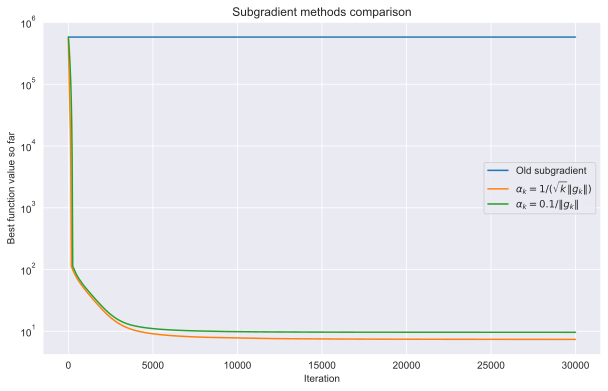

In [ ]:
vals_subg = np.array(list(hist_vals_subg.values()))
vals_subg_1 = np.array(list(hist_vals_subg_1.values()))
vals_subg_a0 = np.array(list(hist_vals_subg_a0.values()))

plt.figure(figsize=(10, 6))

plt.plot(vals_subg, label='Old subgradient')
plt.plot(vals_subg_1, label=r'$\alpha_k = 1 / (\sqrt{k}\|g_k\|)$')
plt.plot(vals_subg_a0, label=rf'$\alpha_k = {a0} / \|g_k\|$')

plt.xlabel('Iteration')
plt.ylabel('Best function value so far')
plt.yscale('log')
plt.title('Subgradient methods comparison')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
iters = 30000
step_ista, step_fista = 1e-3, 3e-4
hist_vals_ista, last_x_ista, hist_x_ista = ISTA(full_oracle, regression_oracle, regularization_oracle, iters, x0, step_ista)
hist_vals_fista, last_x_fista, hist_x_fista = FISTA(full_oracle, regression_oracle, regularization_oracle, iters, x0, step_fista)
hist_vals_subg, best_x_subg, hist_x_subg = subgradient_method_with_step(full_oracle, iters, x0, 1)

In [ ]:
it_ista, vals_ista = dict_to_arrays(hist_vals_ista)
it_fista, vals_fista = dict_to_arrays(hist_vals_fista)
it_subg, vals_subg = dict_to_arrays(hist_vals_subg)

min_ista, min_fista, min_subg = vals_ista.min(), vals_fista.min(), vals_subg.min()
vals_ista, vals_fista, vals_subg = np.log(vals_ista), np.log(vals_fista), np.log(vals_subg)

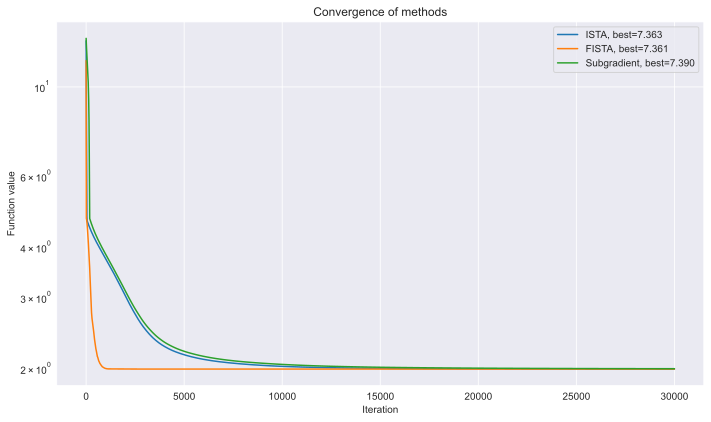

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))


ax.plot(it_ista, vals_ista, label=f"ISTA, best={min_ista:.3f}")
ax.plot(it_fista, vals_fista, label=f"FISTA, best={min_fista:.3f}")
ax.plot(it_subg, vals_subg, label=f"Subgradient, best={min_subg:.3f}")

ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Function value")
ax.set_title("Convergence of methods")
ax.legend()
ax.grid(True)


plt.tight_layout()
plt.show()

**Выводы:** по первому графику видно, что оба варианта выбора шага с делением на норму градиента позволяют методу сойтись к некоему оптимуму за данное число итераций. Я взял a0 = 0.1, что является стандартным вариантом для этого алгоритма. Не исключаю, что при аккуратном подборе этого гиперпараметра он может обойти второй вариант выбора шага, но в текущей конфигурации вариант c 1/sqrt(k)*||g|| оказался лучше как по скорости сходимости, так и по лучшему значению функционала. Именно его я сравнил с ISTA и FISTA (второй график с двойным логарифмированием для лучшего качества графика). По результатам сравнения можно утверждать, что субградиентный метод с таким выбором шага вплотную приблизился по скорости сходимости к ISTA, да и итоговое качество у всех трех алгоритмов выходит примерно одинаковое.

**Бонус 2. (1.5 баллов)** Часто жизнь оказывается такова, что мы не можем подобрать оптимальный константный шаг, потому что это может быть дорого, а константу гладкости функции мы можем и не знать (да, оптимальный размер шага зависит от нее). В этом случае можно искать шаг $\alpha_{k}$ при помощи backtracking search:

$$f(x_{k+1})\leq f(x_k) + \langle \nabla f_k, x_{k+1}-x_k \rangle + \frac{1}{2\alpha_k}\|x_k-x_{k+1}\|^2$$

А в качестве процедуры поиска использовать бинарный поиск

*Замечание.* Внимательный студент может заметить, что в этом случае мы пытаемся подобрать $\alpha_{k}$ так, чтобы оно было похоже на $\frac{1}{L}$, который и является оптимальным размером шага.

Попробуйте реализовать данную стратегию, сравните ее с уже реализованными методами. Дополнительно посчитайте, сколько раз вы вычисляли саму функцию. Сделайте выводы.

In [ ]:
### YOUR CODE HERE

**Выводы:**

### Часть 2 (1.5 балла). ADMM for matrix completion

Рассмотрим задачу восстановления матрицы $Y$. Мы наблюдаем только небольшой набор элементов матрицы $Y$, множество индексов известных элементов обозначим через $E$. То есть мы знаем $Y_{ij}$ для всех $(i,j) \in E$, и не знаем $Y_{ij}$ для всех $(i,j) \notin E$.

Понятно, что без наличия какой-либо дополнительной информации о матрице $Y$ эта постановка является тривиальной: любая матрица $X$, для которой выполнено $X_{i,j} = Y_{i,j}, \quad (i,j) \in E$ является разумным ответом. Таких матриц бесконечно много. Соответственно задача восстановления матриц обычно рассматривается как частный случай задачи приближения матрицы, а критерий качества (целевая функция) говорит не столько о близости $X$ к $Y$, сколько о полезных свойствах матрицы $X$ (этими свойствами матрица $Y$ может и не обладать).

Одна из самых популярных постановок является задача о поиске наилучшего приближения заданной матрицы матрицей малого ранга:

$$
\begin{align*}
& \min_{X} rank(X) \\
& X_{i,j} = Y_{i,j}, \quad (i,j) \in E\\
\end{align*}
$$

В общем случае эта задача является NP-трудной. Для того чтобы обойти это препятствие ранг матрицы аппроксимируется той или иной выпуклой функцией от матрицы $X$. Стандартным выбором является переход к постановке задачи с использованием ядерной нормы

$$
\begin{align*}
& \min_{X}\|X \|_* \\
& X_{i,j} = Y_{i,j}, \quad (i,j) \in E\\
\end{align*}
$$

**Задание 1. (0.5 балла)** Сведите полученную задачу к виду, пригодному для решения с помощью ADMM. Запишите итерации, получите аналитические выражения для каждого шага.

**Решение:**

Пусть $C = \{Z | Z_{ij} = Y_{ij}, (i,j) \in E\}$, тогда $I_C(Z) = (Z \in C)  ? 0 : +inf$

Переформулируем задачу для ADMM:
$$
\begin{align*}
\min_{X}\|X \|_* + I_C(Z) \\
X - Z = 0 \\
\end{align*}
$$

Лагранжиан:

$$
\mathcal{L}_r(X, Z, \Lambda)
=
\|X\|_*
+
I_C(Z)
+
\langle \Lambda, X - Z \rangle
+
\frac{r}{2}\|X - Z\|_F^2
$$

Итерации ADMM:

$$
X^{k+1}
=
\arg\min_X
\|X\|_*
+
\frac{r}{2}
\left\|
X - Z^k + \frac{\Lambda^k}{r}
\right\|_F^2 $$

$$Z^{k+1}
=
\arg\min_Z
I_C(Z)
+
\frac{r}{2}
\left\|
X^{k+1} - Z + \frac{\Lambda^k}{r}
\right\|_F^2 $$

$$\Lambda^{k+1}
=
\Lambda^k
+
r\left(X^{k+1} - Z^{k+1}\right)
$$

Аналитические формулы:

$$
X^{k+1}
=
\arg\min_X
\|X\|_* +
\frac{r}{2}
\left\|
X - Z^k + \frac{\Lambda^k}{r}
\right\|_F^2
$$

SVD:

$$
Z^k - \frac{\Lambda^k}{r} = U \Sigma V^T
$$

Тогда, в итоге:
$$
X^{k+1}
=
U \,\mathrm{diag}\big((\sigma_i - 1/r)_+\big)\, V^T
$$


$$
Z^{k+1}
=
\arg\min_Z
I_C(Z)
+
\frac{r}{2}
\left\|
Z - X^{k+1} - \frac{\Lambda^k}{r}
\right\|_F^2
$$

$$
Z^{k+1}
=
\Pi_C(X^{k+1} + \frac{\Lambda^k}{r})
$$

Итог:
$$
Z^{k+1}_{ij}
=
\begin{cases}
Y_{ij}, & (i,j)\in E \\
B_{ij}, & (i,j)\notin E
\end{cases}
$$


$$
\Lambda^{k+1}
=
\Lambda^k + r(X^{k+1}-Z^{k+1})
$$

**Задание 2.(0.5 балла)** Реализуйте полученные формулы.

*Замечание*. Вы все еще в праве менять интерфейсы функций так, как хотите

In [ ]:
def MC_update_X(Z, lambda_, r):
    """
    Функция, обновляющая значение X для задачи Matrix Completion, используя переменные Z, lambda_ и r
    """
    U, S, Vh = np.linalg.svd(Z-lambda_/r, full_matrices=False)
    S = np.maximum(S - 1/r, 0)
    return (U*S)@Vh


def MC_update_Z(X, lambda_, r, Y, mask):
    """
    Функция, обновляющая значение X для задачи Matrix Completion, используя переменные Z, lambda_, r, Y и маску E
    """
    B = X + lambda_/r
    return mask * Y + (1 - mask) * B


def MC_ADMM(Y, mask, tol, max_iters, r, Y_true):
    """
    Функция, решающая задачу Matrix Completion для известных пикселей Y в точках mask
    Считаем, что метод сходится, если ядерная норма поменялась за итерацию менее чем на tol
    Максимальное количество итераций - max_iters
    Параметр r для ADMM задается в интерфейсе
    Для вычисления различных метрик вам может потребоваться знание исходного изображения
    """
    mask = mask.astype(float)
    X = np.zeros_like(Y)
    Z = np.zeros_like(Y)
    lambda_ = np.zeros_like(Y)
    prev_norm = np.linalg.norm(X, ord='nuc')
    history = {}
    for epoch in range(max_iters):
        X = MC_update_X(Z, lambda_, r)
        Z = MC_update_Z(X, lambda_, r, Y, mask)
        lambda_ = lambda_ + r*(X - Z)
        primal_res = np.linalg.norm(X - Z, ord='fro')
        history[epoch] = primal_res
        new_norm = np.linalg.norm(X, ord='nuc')
        if primal_res < tol:
            break
        prev_norm = new_norm
    return history, X

**Задание 3. (0 баллов)** Выберите любимую картинку, на которой вы будете тестировать алгоритм, покажите ее

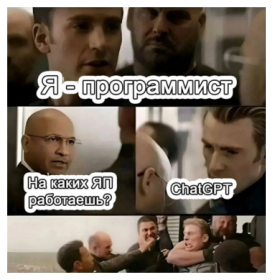

In [ ]:
Y_true = cv2.imread('image.jpg')
Y_true = cv2.cvtColor(Y_true, cv2.COLOR_BGR2RGB) / 255
plt.grid(False)
plt.axis(False)
plt.imshow(Y_true)
plt.show()

**Задание 4.(0.3 балла)** Покажите работоспособность алгоритма:

1) Нарисуйте график зависимости ошибки восстановления картинки от номера итерации

2) Покажите визуально, что он действительно решает задачу восстановления изображения при отсутствии 50 процентов пикселей

*Замечание*. Вы можете работать с изображением как с черно-белым, но интереснее будет запускать ADMM на каждом из каналов :)

In [ ]:
def generate_mask(shape, size, seed=42):
    """
    Генерирует маску для изображения формы shape, оставляющую только size пикселей
    """
    np.random.seed(seed)
    mask = np.full(np.prod(shape), False)
    mask[:size] = True
    np.random.shuffle(mask)
    mask = mask.astype(bool)
    return mask.reshape(shape)

In [ ]:
H, W = Y_true.shape[:2]
size = int(H * W * 0.5)
mask = generate_mask(Y_true.shape[:2], size)
mask = np.repeat(mask[:, :, None], 3, axis=2)
Y = Y_true * mask
tol = 1e-4
hist = {0: None, 1: None, 2: None}
max_iters = 50
r = 1
X = np.zeros_like(Y)
for i in tqdm(range(3)):
    hist[i], X[:,:,i] = MC_ADMM(Y[:,:,i], mask[:,:,i], tol, max_iters, r, Y_true[:,:,i])

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:15<00:00, 25.17s/it]


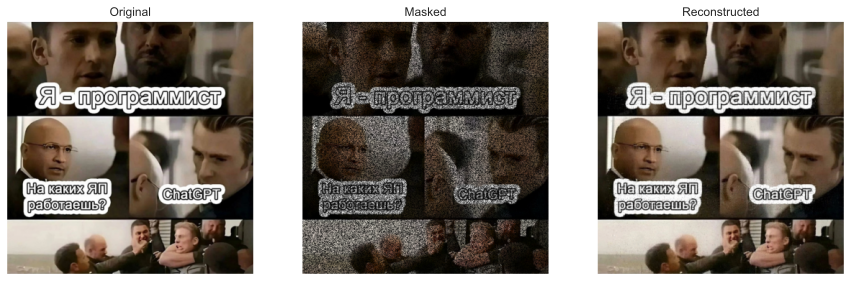

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(Y_true)
plt.title("Original")
plt.axis(False)

plt.subplot(1,3,2)
plt.imshow(Y)
plt.title("Masked")
plt.axis(False)

plt.subplot(1,3,3)
plt.imshow(np.clip(X,0,1))
plt.title("Reconstructed")
plt.axis(False)

plt.show()

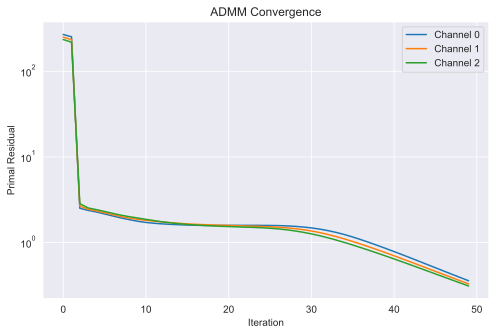

In [ ]:
plt.figure(figsize=(8,5))

for i in range(3):
    epochs = list(hist[i].keys())
    values = list(hist[i].values())
    plt.plot(epochs, values, label=f'Channel {i}')

plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Primal Residual")
plt.title("ADMM Convergence")
plt.legend()
plt.grid(True)
plt.show()

**Задание 5.(0.2 балла)** Посмотрите на то, как влияет количество удаленных пикселей на качество восстановления, как с точки зрения **нормы разности** истинного изображения и восстановленного, так и **с визуальной точки зрения**. Посмотрите удаление 30, 50 и 80 процентов пикселей (приветствуется смотреть и другие значения, например, 90). **ВНИМАНИЕ.** Перечитайте первое предложение внимательно, нужно провести анализ качества восстановления по двум параметра.

*Замечание*. Вы можете работать с изображением как с черно-белым, но интереснее будет запускать ADMM на каждом из каналов :)

In [ ]:
def plot_results(X, Y_true, mask, alphas, figsize=(10, 15)):
    """
    Функция, отрисовывающая получившиеся результаты
    :X - list восстановленных изображений (цветных)
    :Y_true - настоящее изображение
    :mask - list масок
    :alphas - list состоящий из долей удаленных пикселей
    Функция написана в предположении, что Вы работаете с цветными изображениями, если вы выбрали работать с чб, то
    не забудьте поменять код
    """
    fig, ax = plt.subplots(nrows=len(X), ncols=3, figsize=figsize)
    for j in range(len(X)):
        tmp = np.copy(Y_true)
        current_mask = np.stack((~mask[j], ~mask[j], ~mask[j]), axis=2)
        tmp[current_mask] = 0
        content = [Y_true, tmp, X[j]]
        primal_res = np.linalg.norm(X[j] - Y_true)
        titles = ["Оригинальное изображение",
          f"Изображение с удаленными\n {int((1-alphas[j]) * 100)}% пикселями",
          f"Восстановленное изображение,\n  норма разности = {primal_res:.3f}"]
        for i in range(3):
            ax[j][i].set_title(titles[i])
            ax[j][i].imshow(content[i])
            ax[j][i].grid(False)
            ax[j][i].axis(False)
    plt.show()

In [ ]:
percents = [0.7, 0.5, 0.2, 0.1]
H, W = Y_true.shape[:2]
list_X = []
masks = []
with tqdm(total=4) as pbar:
    for j in range(len(percents)):
        size = int(H * W * percents[j])
        mask = generate_mask(Y_true.shape[:2], size)
        masks.append(mask)
        mask = np.repeat(mask[:, :, None], 3, axis=2)
        Y = Y_true * mask
        tol = 1e-4
        hist = {0: None, 1: None, 2: None}
        max_iters = 100
        r = 1
        list_X.append(np.zeros_like(Y))
        for i in range(3):
            _, X = MC_ADMM(Y[:,:,i], mask[:,:,i], tol, max_iters, r, Y_true[:,:,i])
            list_X[j][:,:,i] = np.clip(X, 0, 1)
        pbar.update(1)

100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [10:59<00:00, 164.77s/it]


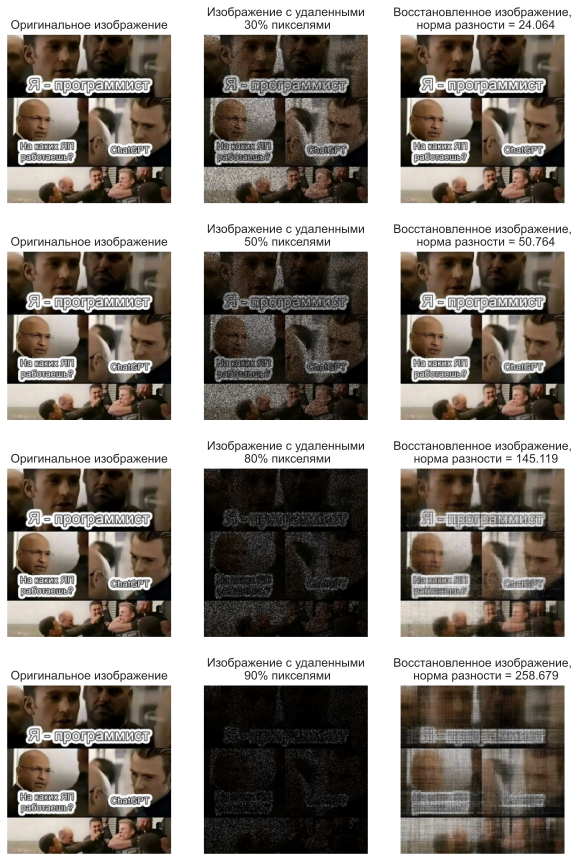

In [ ]:
plot_results(list_X, Y_true, masks, percents)

**Вывод**: очевидно, чем больше процентов пикселей убирается, тем хуже идет восстановление изображения. При 100 итерациях приемлемое качество восстановленного изображения получается при 30 и 50 процентах убранных изображений, при 80 тоже неплохо относительно (по крайней мере различим текст). Это подтверждают и нормы разности между изображениями, которые растут (на глаз) экспоненциально по отношению к количеству удаленных пикселей.

### Часть 3. (2.95 баллов) Редукция дисперсии

Часто при обучении нейронных сетей возникает вопрос выбора параметра `batch_size`, как вы знаете батчирование (разбирали на паре) помогает уменьшить дисперсию стохастического градиента и следовательно улучшает сходимость. К сожалению, на практике мы не можем взять `batch_size` достаточно большим из-за ограничений видеопамяти, а стохастический градиент все еще достаточно шумный (имеет высокую дисперсию).

В этой части Вам предлагается реализовать метод **SVRG** и продемонстрировать его работу.

*Замечание*: в базовой реализации мы будем предполагать, что раз в $N$ итераций мы сможем сделать `backward pass` с большим батчом. На практике такое предположение не выполняется. Исправление данной проблемы является чисто технической задачей, которую не обязательно решать в учебных целях.

**Важно:** В этой части для написания выводов вам потребуются графики обучения. Без графиков и выводов пункт **не будет** засчитан. Все логи и необходимой код для отрисовки графиков написан за вас через `wandb`, который умеет автоматически формировать отчеты. Чтобы ваш ноутбук не весил десятки мегабайт прикладывайте отчет отдельно! Подробнее можно изучить либо в документации `wandb` либо [на видео](https://www.youtube.com/watch?v=2xeJIv_K_eI&ab_channel=Weights%26Biases).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import os
import random
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision.datasets import MNIST
import torchvision.transforms as transforms

In [ ]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_global_seed(42)

**Задание 1. (0.1 баллов)** Предварительные сведения


При реализации **SVRG** вам потребуется сохранять веса и градиенты модели. В этом задании вам предлагается поменять местами (свапнуть) веса двух моделей с целью упражнения и упрощения понимания дальнейшего кода.

*Подсказка 1:* Обратите внимание на функцию `copy.deepcopy`

*Замечание:* Вы можете использовать функции `set_weights`, `set_grad`, но также можно реализовать их сами

**Важно:** `copy.deepcopy` не копирует градиенты, которые хранятся в параметрах нейронной сети [источник 1](https://github.com/pytorch/pytorch/issues/3307) [источник 2](https://github.com/pytorch/pytorch/issues/95711). Поэтому в дальнейшем крайне рекомендуется использовать функцию `set_grad` и `set_weights`. В противном случае у вас, скорее всего, где-то будет ошибка.

In [ ]:
@torch.no_grad()
def set_weights(parameters, parameters_new):
    """
    Функция устанавливает веса parameters_new как веса для parameters
    """
    for p1, p2 in zip(parameters, parameters_new):
        p1.data = p2.data.detach().clone()

@torch.no_grad()
def set_grad(parameters, parameters_new):
    """
    Функция устанавливает градиенты parameters_new как градиенты для parameters
    """
    for p1, p2 in zip(parameters, parameters_new):
        if p2.grad is not None:
            p1.grad = p2.grad.detach().clone()

In [ ]:
# Нейросети, веса которых вам нужно поменять местами
set_global_seed(42)

net1 = nn.Sequential(nn.Linear(4, 4), nn.ReLU())
net2 = nn.Sequential(nn.Linear(4, 4), nn.ReLU())

net1_p = list(net1.parameters())
net2_p = list(net2.parameters())

print("Параметры net1\n", net1_p)
print("Параметры net2\n", net2_p)

Параметры net1
 [Parameter containing:
tensor([[ 0.3823,  0.4150, -0.1171,  0.4593],
        [-0.1096,  0.1009, -0.2434,  0.2936],
        [ 0.4408, -0.3668,  0.4346,  0.0936],
        [ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True), Parameter containing:
tensor([ 0.3854,  0.0739, -0.2334,  0.1274], requires_grad=True)]
Параметры net2
 [Parameter containing:
tensor([[-0.2304, -0.0586, -0.2031,  0.3317],
        [-0.3947, -0.2305, -0.1412, -0.3006],
        [ 0.0472, -0.4938,  0.4516, -0.4247],
        [ 0.3860,  0.0832, -0.1624,  0.3090]], requires_grad=True), Parameter containing:
tensor([ 0.0779,  0.4040,  0.0547, -0.1577], requires_grad=True)]


Поменяйте местами веса моделей, код необходимо написать ниже

In [ ]:
net_buf = nn.Sequential(nn.Linear(4, 4), nn.ReLU())
set_weights(net_buf.parameters(), net1.parameters())
set_weights(net1.parameters(), net2.parameters())
set_weights(net2.parameters(), net_buf.parameters())

In [ ]:
print("Параметры net1 после обмена\n", list(net1.parameters()))
print("Параметры net2 после обмена\n", list(net2.parameters()))

Параметры net1 после обмена
 [Parameter containing:
tensor([[-0.2304, -0.0586, -0.2031,  0.3317],
        [-0.3947, -0.2305, -0.1412, -0.3006],
        [ 0.0472, -0.4938,  0.4516, -0.4247],
        [ 0.3860,  0.0832, -0.1624,  0.3090]], requires_grad=True), Parameter containing:
tensor([ 0.0779,  0.4040,  0.0547, -0.1577], requires_grad=True)]
Параметры net2 после обмена
 [Parameter containing:
tensor([[ 0.3823,  0.4150, -0.1171,  0.4593],
        [-0.1096,  0.1009, -0.2434,  0.2936],
        [ 0.4408, -0.3668,  0.4346,  0.0936],
        [ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True), Parameter containing:
tensor([ 0.3854,  0.0739, -0.2334,  0.1274], requires_grad=True)]


Попробуем теперь свапнуть местами градиенты.

*Подсказка 1:* Чтобы было куда сохранять градиенты надо будет сделать копию параметров

In [ ]:
x = torch.ones((1, 4))
net1(x).sum().backward()

x = torch.arange(4).reshape(1, 4).float()
net2(x).sum().backward()

print("Градиенты net1\n", list(p.grad for p in net1.parameters()))
print("Градиенты net2\n", list(p.grad for p in net2.parameters()))

Градиенты net1
 [tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [1., 1., 1., 1.]]), tensor([0., 0., 0., 1.])]
Градиенты net2
 [tensor([[0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.]]), tensor([1., 1., 1., 1.])]


In [ ]:
set_grad(net_buf.parameters(), net1.parameters())
set_grad(net1.parameters(), net2.parameters())
set_grad(net2.parameters(), net_buf.parameters())

In [ ]:
print("Градиенты net1 после обмена \n", list(p.grad for p in net1.parameters()))
print("Градиенты net2 после обмена \n", list(p.grad for p in net2.parameters()))

Градиенты net1 после обмена 
 [tensor([[0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.]]), tensor([1., 1., 1., 1.])]
Градиенты net2 после обмена 
 [tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [1., 1., 1., 1.]]), tensor([0., 0., 0., 1.])]


**Задание 2. (0.2 баллов)** Реализуйте `SGD`

В качестве базового класса будем использовать [torch.optim.Optimizer](https://pytorch.org/docs/stable/optim.html#base-class). Цель этого пункта познакомить вас с тем, как внутри оптимизатора лежат веса и градиенты модели. Вам же необходимо написать шаг стохастического градиентного спуска.

**Подсказка 1:** Обратите внимание на функцию `torch.add` и ее аргументы.

In [ ]:
class SGDBase(optim.Optimizer):

    def __init__(self, params, lr):

        # Определение Базового класса
        defaults = dict(lr=lr)
        super().__init__(params, defaults)

    def step(self):

        # Итерация по всем группам параметров
        for group in self.param_groups:

            # Итерация по всем параметрам
            for p in group['params']:

                # Проверка на то, обучаем ли параметр
                if p.grad is None:
                    continue
                with torch.no_grad():
                    torch.add(p, p.grad, alpha=-group['lr'], out=p)


Проверим работоспособность на простой функции и сравним наш алгоритм, с реализацией `optim.SGD`

In [ ]:
def foo(x):
    return (x - 1.0) ** 2

def testing_optimizer(x_0, optimizer_class, num_steps=10):
    x = nn.Parameter(data=x_0.clone()) # x - обучаемый параметр
    optimizer = optimizer_class([x], lr=0.1)
    history = [x.item()]

    for _ in range(num_steps):
        optimizer.zero_grad()

        loss = foo(x)
        loss.backward()

        optimizer.step()
        history.append(x.item())


    return np.array(history)

In [ ]:
x_0 = torch.tensor(10.0)
history_pytorch = testing_optimizer(x_0, optimizer_class=optim.SGD)
history_pytorch

array([10.        ,  8.19999981,  6.75999975,  5.6079998 ,  4.68639994,
        3.94912004,  3.35929608,  2.88743687,  2.50994945,  2.20795965,
        1.96636772])

In [ ]:
history_base = testing_optimizer(x_0, optimizer_class=SGDBase)
history_base

array([10.        ,  8.19999981,  6.75999975,  5.6079998 ,  4.68639994,
        3.94912004,  3.35929608,  2.88743687,  2.50994945,  2.20795965,
        1.96636772])

In [ ]:
assert (history_base == history_pytorch).all()

**Задание 3. (0.3 баллов)** Обертка над шагом обучения

Для дальнейшего удобства использования, напишем небольшой класс-обертку. Такой ход позволит скрыть от цикла обучения все функции связанные с шагом обучения. Благодаря этому мы сможем добавить **SVRG** (который влияет только на итерацию обучения) переопределив класс-обертку. Тем самым наша реализация **SVRG** будет спрятана в обертки и не будет влиять на код цикла обучения.

*Замечание:* Ниже в целях уменьшения кода, мы предполагаем что в оптимизаторе только одна группа параметров. То есть оптимизаторы вида:

```python

optim.Adam([
        {"params": net1.parameters(), "lr": lr1},
        {"params": net2.parameters(), "lr": lr2},
    ...
    ])

```

**НЕ** будут поддерживаться

**Важно:** Внимательно изучите функции класса-обертки и базовый пример. В дальнейшем мы будем переопределять функцию `step_fn` для SVRG.

In [ ]:
class WrapperBase:

    def __init__(self, optimizer, loss_fn):
        """
        :optimizer - базовый оптимизатор
        :loss_fn - функция по батчу вычисляющая loss и другие важные в ходе обучения значения.
        Функция возвращает словарь, в котором обязательно присутсвует ключ 'loss'.
        Значение функции потерь храняться по ключу 'loss'

        """
        self.optimizer = optimizer
        self.loss_fn = loss_fn

    def get_param_groups(self):
        """
        return
        Ссылку на параметры модели, т.е. изменение значения, меняет значение внутри модели

        Замечание: захардкожено [0]
        """
        return self.optimizer.param_groups[0]['params']

    def get_group(self):
        """
        return
        Возвращает группу параметров оптимизатора

        Замечание: захардкожено [0]
        """
        return self.optimizer.param_groups[0]

    def zero_grad(self):
        """
        Обнуляет все градиенты для параметров оптимизатора
        """
        self.optimizer.zero_grad()

    def step(self):
        """
        Производит шаг оптимизатора
        """
        self.optimizer.step()

    def step_fn(self, batch):
        """
        Считает все статистики на батче, производит шаг оптимизации
        return
        Все необходимые статистики для логирования
        """
        self.zero_grad()
        stat_dict = self.loss_fn(batch)
        stat_dict['loss'].backward()
        self.step()
        return stat_dict

Тогда мы можем переписать `testing_optimizer` следующим образом

In [ ]:
def testing_optimizer_wrapper(x_0, optimizer_class, num_steps=10):
    x = nn.Parameter(data=x_0.clone()) # x - обучаемый параметр
    optimizer = optimizer_class([x], lr=0.1)
    optimizer_wrapper = WrapperBase(optimizer, lambda x: {'loss': foo(x)})

    history = [x.item()]

    for _ in range(num_steps):
        optimizer_wrapper.step_fn(x)
        history.append(x.item())


    return np.array(history)

In [ ]:
x_0 = torch.tensor(10.0, requires_grad=True)
history = testing_optimizer(x_0, optimizer_class=optim.SGD)
history_wrapper = testing_optimizer_wrapper(x_0, optimizer_class=optim.SGD)

In [ ]:
assert (history == history_wrapper).all()

**Задание 4. (0.75 баллов)** **SVRG**

Реализуем метод `SVRG` как обёртку над базовым классом оптимизатора (оптимизатор используем условно как удобный интерфейс)

Для начала напомним вид алгоритма из семинара:

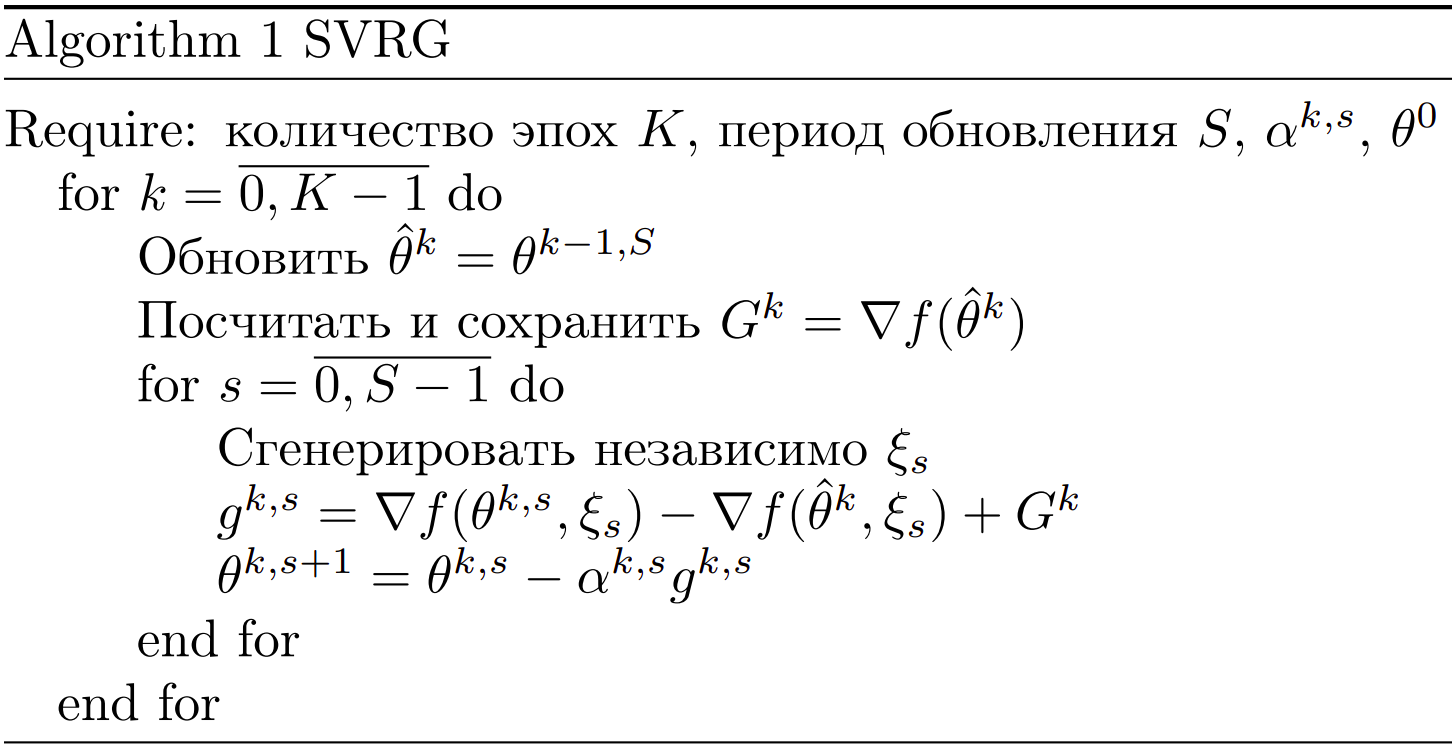

**ВАЖНО**

Мы будем реализовывать чуть другую версию:
    
```python

for i in range(1, N):
    if i % S == 0:
        w_large := w
        Обновить G_s           # градиент по всей выборки (большому батчу) при весах w_large
        
    Засэмплировать батч        # batch
    g_main                     # градиент по batch при весах w
    g_bias                     # градиент по batch при весах w_large
    g = g_main - g_bias + G_s
    
    w = w - lr * g
```

*Замечание:* Вы можете менять интерфейсы классов так, как считаете нужным, предложенный вариант - один из возможных. Главное, чтобы все работало

*Подсказка 1:* Для получения весов по которым ведется оптимизация (веса обучаемой нейронной сети) можно использовать `WrapperBase.get_param_groups()`.

In [ ]:
class SVRG(WrapperBase):

    def __init__(self, optimizer, loss_fn, data, S):
        """
        optimizer: базовый оптимизатор
        loss_fn: функция по батчу вычисляющая loss и другие важные в ходе обучения значения.
        Функция возвращает словарь, в котором обязательно присутсвует ключ 'loss'.
        Значение функции потерь храняться по ключу 'loss'
        data: вся выборка или батч большого размера, по которому считается градиент раз в S итераций
        S: параметр указывающий период пересчета градиента по всей выборки
        """

        super().__init__(optimizer=optimizer, loss_fn=loss_fn)
        self.data = data
        self.S = S
        self.counter = 0

    def step_fn(self, batch):

        # Обнуление градинетов модели, чтобы не накладывались при следующих вычислениях
        self.zero_grad()

        # Подсчет градиента на батче
        stat_main = self.loss_fn(batch)
        stat_main['loss'].backward()

        # Сохранение градиентов и весов посчитанных на батче
        params_cur = [p.detach().clone() for p in self.get_param_groups()]
        grads_cur = [p.grad.detach().clone() for p in self.get_param_groups()]


        # Обнуление градинетов модели, чтобы не накладывались при следующих вычислениях
        self.zero_grad()

        if self.counter == 0:
            # Подсчет градиента на большом множестве
            stat_dict = self.loss_fn(self.data)
            stat_dict['loss'].backward()


            # Сохранение градиентов и весов посчитанных на большом батче
            self.params_large = [p.detach().clone() for p in self.get_param_groups()]
            self.grads_large = [p.grad.detach().clone() for p in self.get_param_groups()]

            # Обнуление градинетов модели, чтобы не накладывались при следующих вычислениях
            self.zero_grad()


        # Установка весов модели (для которой считали градиент на большом батче)
        set_weights(self.get_param_groups(), self.params_large)
        self.zero_grad()

        # Подсчет градиента на батче для поправки
        stat_dict = self.loss_fn(batch)
        stat_dict['loss'].backward()


        # Сохранение градиентов посчитанных на батче поправки
        grads_bias = [p.grad.detach().clone() for p in self.get_param_groups()]

        # Востановлние весов и градиентов прошлой модели
        set_weights(self.get_param_groups(), params_cur)

        for p_main, g_main, g_bias, G_s in zip(self.get_param_groups(), grads_cur, grads_bias, self.grads_large):
            d_p = g_main - g_bias + G_s
            if p_main.grad is None:
                p_main.grad = d_p.detach().clone()
            else:
                p_main.grad.copy_(d_p.detach())

        # Шаг основного оптимизатора с новыми градиентами
        self.step()

        # Обновление счётчика
        self.counter += 1

        if self.counter == self.S:
            self.counter = 0

        return stat_main


**Задание 5: демонстрация использования оптимизатора (0 баллов)**: Эксперименты на  `MNIST`
    
Для корректных выводов по работе  **SVRG** нам необходимо:

1) Задача на реальных данных

2) Baseline решения этой задачи


В качестве данных предлагается `MNIST`, в качестве Baseline следующий код.


Напомним, что **SVRG** придуман для понижения дисперсии стохастического градиента. Поэтому будем иметь 2 стандартных решения: с высокой и низкой дисперсией стохастического градиента.


Вам необходимо обучить 2 и больше модели, с которыми Вы дальше будете сравниваться. Предполагается, что у одной модели будет **высокая** дисперсия стохастического градиента, а у другой **низкая**. Другие модели тоже можно обучать для вывода (но эти 2 необходимо получить).


**Важно**: Все эксперименты должны быть воспроизводимы, поэтому фиксируете сид

**Важно**: Если будете менять обучение, постарайтесь, чтобы оно не заняло более 10 минут вычислений на гпу для 1 модели

*Замечание:* Весь код ниже можно менять, главное выполнить задание 6 и показать 2 baseline, с которыми Вы дальше будете сравниваться

**Подсказка 1:** Для всех результатов достаточно 1к итераций. Если метод который должен был сойтись не сошелся за 1к итераций, то скорее всего где-то ошибка.



In [ ]:
device = "cpu"

if torch.cuda.is_available():
    device = "cuda:0"

device

'cpu'

`Подготовка данных`

В качестве предобработки мы будем только нормализовывать данные.

In [ ]:
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.5), std=(0.5))])

train_dataset = MNIST(root=data_dir, train=True, download=True,
                      transform=transform)

test_dataset = MNIST(root=data_dir, train=False, download=True,
                     transform=transform)

`Архитектура модели`

Так как мы решаем задачу классификации `MNIST`, то нам хватит очень маленького MLP. Наша цель не выбить выше качество, а исследовать влияние стохастического градиента.

In [ ]:
class MnistClassifier(nn.Module):

    def __init__(self, hidden_dim=10, image_dim=28):

        super().__init__()

        self.fc_input = nn.Sequential(nn.Flatten(),
                                      nn.Linear(image_dim ** 2, hidden_dim),
                                      nn.SiLU())

        self.fc_out = nn.Sequential(nn.Linear(hidden_dim, 10))


    def forward(self, x):

        return self.fc_out(self.fc_input(x))

Определение `loss_fn` для класса обертки. Выше мы писали класс-обертке, в котором использовалась функция `loss_fn`. Так как мы решаем задачу классификации, то разумно считать значения функции потерь и точность на батче. Если вы считаете, что необходимо считать какие-либо другие метрики, то добавьте их вычисление внутри `loss_fn`.


**Важно:** В DL очень часто практикуется подход, в котором все необходимые вычисления по батчу инкапсулируются внутри одной функции. Код обучения с единой функцией `loss_fn` является хорошим примером такого похода.

In [ ]:
def loss_fn_constructor(model, device):
    criterion = nn.CrossEntropyLoss(reduction='mean')

    def loss_fn(batch):
        X_batch, y_true = batch

        X_batch = X_batch.to(device)
        y_true = y_true.to(device)

        out = model(X_batch)
        loss = criterion(out, y_true)

        y_pred = torch.argmax(out, 1)
        accuracy = torch.sum(y_pred == y_true) / y_pred.shape[0]

        return {'loss': loss, 'accuracy': accuracy}

    return loss_fn

**Логирование**

Для проведения экспериментов вам потребуется отслеживать следующие показатели:

- Дисперсия стохастического градиента

- Значения loss и accuracy на train и test

- Дисперсия весов модели

Для логирования Вы можете использовать любые библиотеки либо собирать данные во время обучения и выводить их после. Здесь предложена реализация через wandb, но вы можете ее не использовать.

**ВАЖНО**

1. Без графиков или иных подтверждающих результатов работа не будет засчитана

2. Все графики должны быть в ноутбуке или отдельном отчете, то есть нельзя прикреплять ссылки на запуск

3. Все запуски должны быть воспроизводимы при последовательном выполнении ячеек

In [ ]:
import wandb

Ниже предложен код логирования дисперсии градиентов и обучаемыех весов модели.

In [ ]:
@torch.no_grad()
def log_variance(model, global_step, experiment):
    for tag, value in model.named_parameters():
        g = value.grad
        if g is None:
            continue

        grad_var = torch.var(g.detach().cpu()).item()
        param_var = torch.var(value.detach().cpu()).item()

        experiment.log_metric(
            name=f"grad_var/{tag}",
            value=grad_var,
            step=global_step
        )

        experiment.log_metric(
            name=f"params_var/{tag}",
            value=param_var,
            step=global_step
        )

In [ ]:
@torch.no_grad()
def log_variance(model, global_step):
    for tag, value in model.named_parameters():
        g = value.grad
        if g is None:
            continue

        wandb.log({f"grad_var/{tag}": torch.var(g.cpu())}, global_step)
        wandb.log({f"params_var/{tag}": torch.var(value.data.cpu())}, global_step)

**Обучение**

Так как **SVRG** обновляет большой градиент каждые $S$ итераций, то для чистоты эксперимента будем обучать каждую модель фиксированное число итераций.

In [ ]:
@torch.no_grad()
def evaluate(net, valid_dataloader, criterion_fn, device):
    net.eval()
    loss, accuracy = 0, 0
    count = 0
    for X_batch, y_true in valid_dataloader:
        X_batch = X_batch.to(device)
        y_true = y_true.to(device)

        out = net(X_batch)
        y_pred = torch.argmax(out, 1)

        bs = out.shape[0]
        loss += criterion_fn(out, y_true).item() * bs
        accuracy += torch.sum(y_pred == y_true).item()
        count += bs

    return loss / count, accuracy / count



def train(iters_num, net, optimizer_wrapper, criterion_fn, train_dataloader, valid_dataloader, device, name):

    #wandb.init(project="mmro_mmp", name=name)
    experiment = Experiment(project_name="mmro_mmp")
    experiment.set_name(name)
    global_step = 1
    net = net.to(device)

    iters_per_epoch = len(train_dataloader)
    epoch_num = iters_num // iters_per_epoch + (iters_num % iters_per_epoch != 1)

    for _ in tqdm(range(epoch_num)):
        for batch in train_dataloader:

            d = optimizer_wrapper.step_fn(batch)
            loss = d['loss']
            accuracy = d['accuracy']

            log_variance(net, global_step, experiment)
            #wandb.log({"train/loss": loss.item(), "train/accuracy": accuracy.item()}, step=global_step)
            experiment.log_metrics({"train/loss": loss.item(), "train/accuracy": accuracy.item()}, step=global_step)

            if global_step % 50 == 0:

                loss, accuracy = evaluate(net, valid_dataloader, criterion_fn, device)
                net.train()

                #wandb.log({"eval/loss": loss, "eval/accuracy": accuracy}, step=global_step)
                experiment.log_metrics({"eval/loss": loss, "eval/accuracy": accuracy}, step=global_step)


            if global_step == iters_num:
                break

            global_step += 1

    #wandb.finish()
    experiment.end()

Продемонстрируем как получить модель с низкой дисперсией стохастического градиента

*Замечание*: Параметры архитектуры и количество итераций желательно не менять (все необходимые результаты можно получить и не изменяя их)

In [ ]:
set_global_seed(42)

net = MnistClassifier(hidden_dim=10)
loss_fn = loss_fn_constructor(model=net, device=device)

optimizer = optim.SGD(net.parameters(), lr=1e-2)
optimizer_wrapper = WrapperBase(optimizer=optimizer, loss_fn=loss_fn)

train_dataloader = DataLoader(train_dataset, batch_size=1024, shuffle=True, drop_last=True)
val_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

criterion_fn = nn.CrossEntropyLoss(reduction='mean')

In [ ]:
train(
    iters_num=1_000,
    net=net,
    optimizer_wrapper=optimizer_wrapper,
    criterion_fn=criterion_fn,
    train_dataloader=train_dataloader,
    valid_dataloader=val_dataloader,
    device=device,
    name="SGD_bs_1024")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/egorpo005/mmro-mmp/650428269c814cc9b1b7633bab16a4ae

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
100%|██████████| 18/18 [04:08<00:00, 13.82s/it]
COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : SGD_bs_1024
COMET INFO:     url                   

При правильной реализации accuracy на тесте будет  `∼0.88`

**Задание 6. (0.5 баллов)**: получите модель с высокой дисперсией стохастического градиента



In [ ]:
set_global_seed(42)

net = MnistClassifier(hidden_dim=10)
loss_fn = loss_fn_constructor(model=net, device=device)

optimizer = optim.SGD(net.parameters(), lr=1e-2)
optimizer_wrapper = WrapperBase(optimizer=optimizer, loss_fn=loss_fn)

train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=True)
val_dataloader = DataLoader(test_dataset, batch_size=2, shuffle=False)

criterion_fn = nn.CrossEntropyLoss(reduction='mean')

In [ ]:
train(
    iters_num=1_000,
    net=net,
    optimizer_wrapper=optimizer_wrapper,
    criterion_fn=criterion_fn,
    train_dataloader=train_dataloader,
    valid_dataloader=val_dataloader,
    device=device,
    name="SGD_bs_2")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/egorpo005/mmro-mmp/630a152ebd0c4b01a80c64f379d43cad

100%|██████████| 1/1 [01:45<00:00, 105.46s/it]
COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : SGD_bs_2
COMET INFO:     url                   : https://www.comet.com/egorpo005/mmro-mmp/630a152ebd0c4b01a80c64f379d43cad
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     eval/accuracy [20] 

При правильной реализации accuracy на тесте будет  ` > 0.74`

**Сделайте выводы**: как влияет дисперсия градиента на обучение (loss, accuracy)

Обязательно продемонстрируйте графики, подтверждающие Ваши выводы.


Ссылка на мои эксперименты на comet: https://www.comet.com/egorpo005/mmro-mmp/view/new/panels

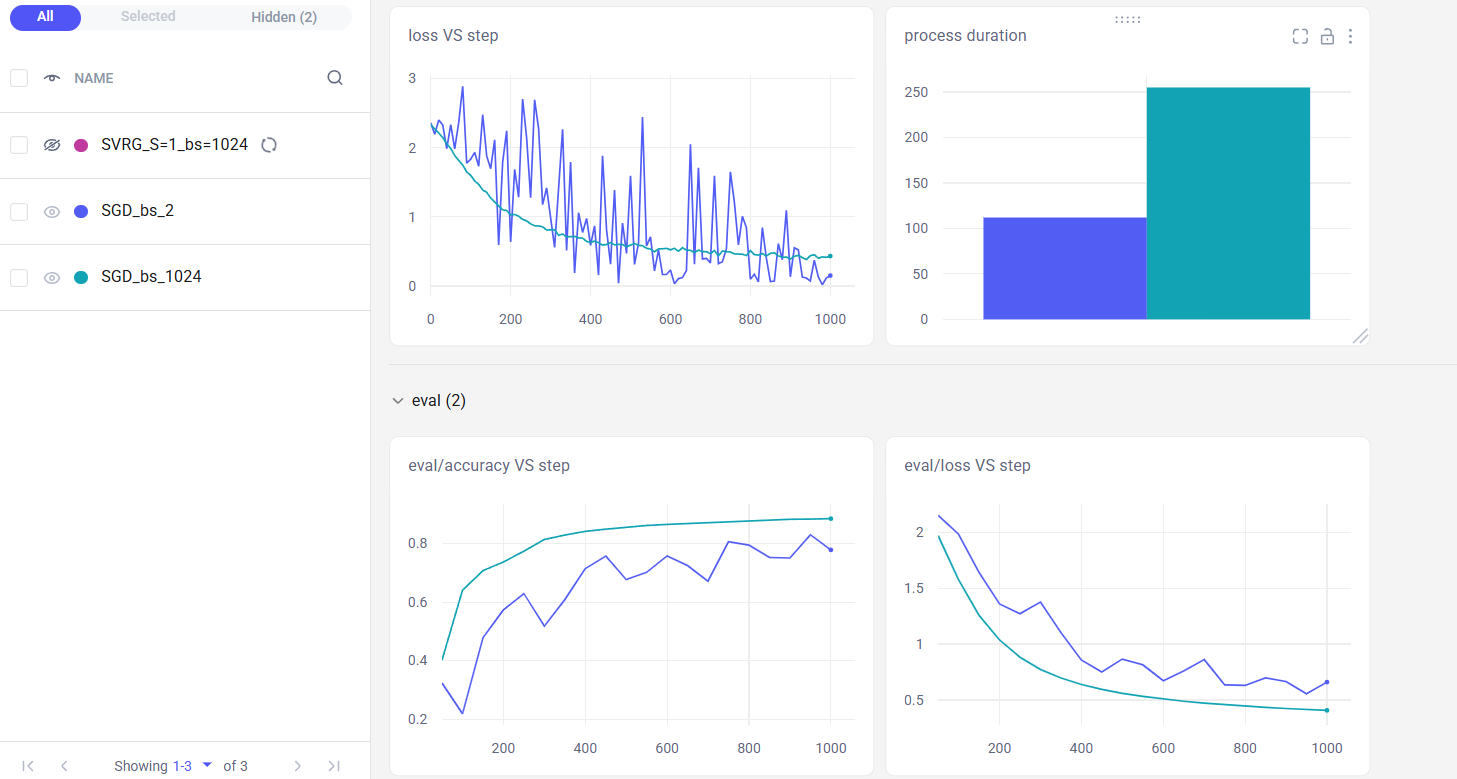

**Вывод**: при увеличении дисперсии градиента обучение становится менее стабильным, "скачут" лосс и accuracy. Получается, что алгоритм не может адекватно сойтись в оптимум, а прыгает вокруг него, конечно, понемногу приближаясь к минимуму, но не так быстро, как могло бы быть при меньшей дисперсии. При этом надо отметить, что при уменьшении размера батча (то бишь увеличении дисперсии) время обучения становится меньше (в данном случае примерно в 2,5 раза)

**Задание 7. (0.1 баллов)**: проверка **SVRG**

Выберите подмножество обучающего датасета, по которому будете считать "честный" градиент. Это может быть либо сам датасет, либо батч размера сильно больше, чем батч обучающей выборки.

**Важно:** Убедитесь, что выбранный вами батч не смещен, т.е. присутствуют все классы в равных пропорциях

In [ ]:
full_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
data = next(iter(full_loader))

Для проверки корректности и адекватности реализации метода следует провести отладочные эксперименты. Основная задача отладочных экспериментов в максимально простых условиях проверить метод. В чем заключается проверка метода? Вы выдвигаете какую-то гипотезу (ожидаемое поведение) и проверяете как работает ваша реализация.

Для проверки корректности вашей реализации **SVRG**, для этого предлагается провести следующий эксперимент:

Если выбрать `S = 1`, то ожидается что обучение станет похожим на градиентный спуск, т.е. траектории обучения похожи на запуск с большим `batch_size`.

Обратите, что функция `step_fn` возвращает значения функций на батче обучающей выборки, т.е. значения достаточно шумные

In [ ]:
set_global_seed(42)

net = MnistClassifier(10)
loss_fn = loss_fn_constructor(model=net, device=device)

optimizer = optim.SGD(net.parameters(), lr=1e-2)
optimizer_wrapper = SVRG(optimizer=optimizer, loss_fn=loss_fn, data=data, S=1)

train_dataloader = DataLoader(train_dataset, batch_size=1024, shuffle=True, drop_last=True)
val_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

criterion_fn = nn.CrossEntropyLoss(reduction='mean')

In [ ]:
train(
    iters_num=1000,
    net=net,
    optimizer_wrapper=optimizer_wrapper,
    criterion_fn=criterion_fn,
    train_dataloader=train_dataloader,
    valid_dataloader=val_dataloader,
    device=device,
    name="SVRG_S=1_bs=1024")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/egorpo005/mmro-mmp/e295e423c1684707b4ec90b8be413f94

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
100%|██████████| 18/18 [05:00<00:00, 16.70s/it]
COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : SVRG_S=1_bs=1024
COMET INFO:     url              

При правильной реализации accuracy на тесте будет  `∼0.88`

Насколько согласована реально полученная картина с ожиданиями? Сделайте выводы.
    

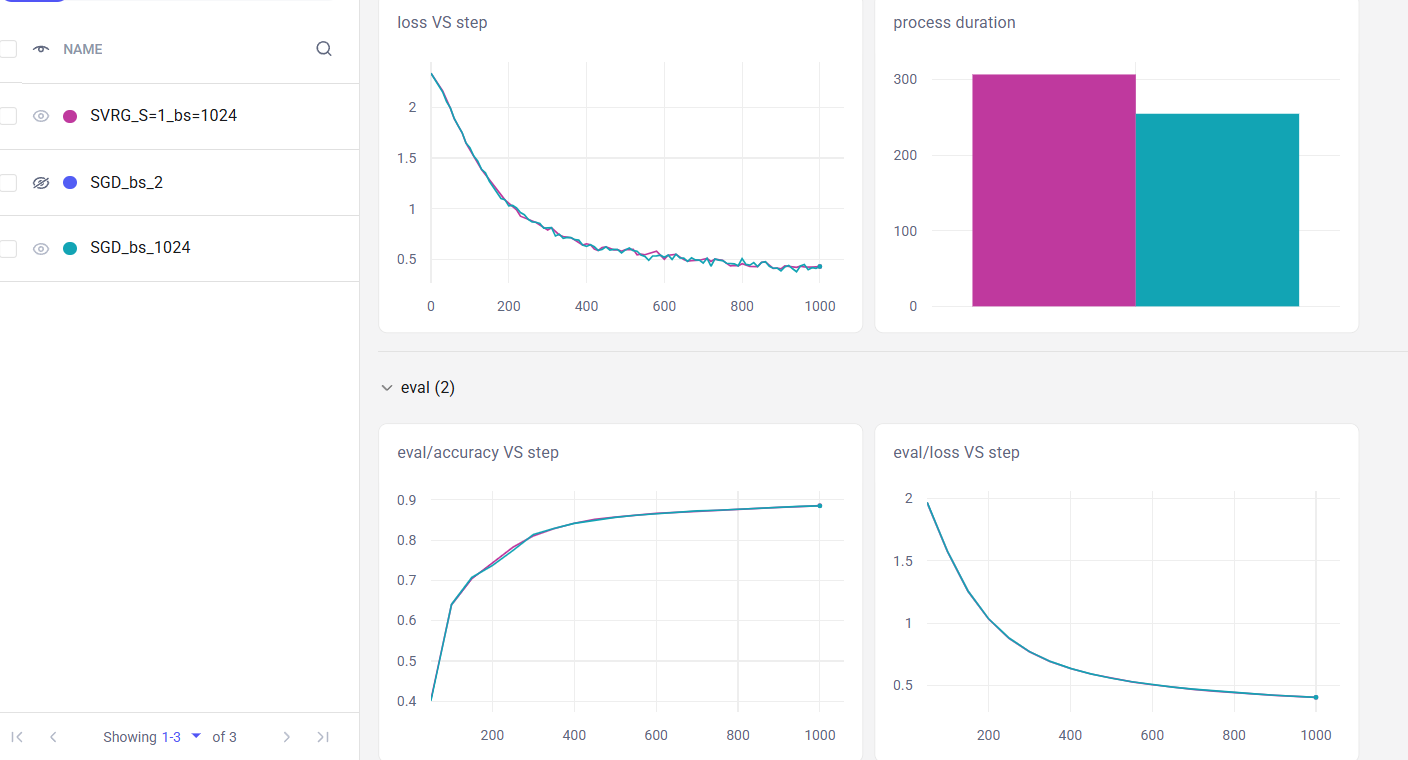

**Вывод**: кривые обучения действительно полностью совпадают с обычным градиентным спуском (в нашем случае это видно по почти полному совпадению с SGD с относительно большим батчем в 1024 объекта). Уменьшение лосса и увеличение accuracy очень гладкие из-за полного подсчета градиента (я за data взял весь датасет, поэтому как раз и время выполнение больше, чем у SGD с batch_size=1024)

**Задание 8. (1 балл)**: Эксперименты (если у вас 1 запуск занимает 1 минуту, то секция должна выполняться не более 16 минут)

Запуск будет считаться **корректным** если соблюдаются следующие правила:

1) Выберите подмножество обучающей выборки `data`, по которому будете считать честный градиент.

2) Так как цель метода, без особой вычислительной нагрузки уменьшить дисперсию, то размер `data` и значение `S` нужно выбрать разумными. Разумным считаются такие параметры, при которых количество подсчетов градиентов от элемента выборки во время обучения увеличиться не более чем в 6 раз.


Пример **НЕ** правильного подбора:

`batch_size = 2`

`len(data) = 50000`

`S = 1`


Каждая итерация обучения в среднем будет делать `50002` подсчетов градиента, вместо 2

Пример разумного подбора:

`batch_size = 2`

`len(data) = 256`

`S = 100`

Каждая итерация обучения в среднем будет делать `4.56` подсчетов градиента, вместо 2

**Важно**: правила можно нарушать для проверки и демонстрации граничных случаев, но базовые эксперименты все равно должны быть продемонстрированы

Цель эксперимента:

Продемонстрировать как меняется обучение от размера `data` и параметра `S`.

Необходимы минимум перебора параметров:

$S = 100, 300, 500$

$len(data) = 256$ и любой на ваше усмотрение, который согласуется с правилами выше.


Минимальные показатели, по которым должны быть сделаны выводы:

1) Лучшие показатели accuracy, loss на валидации

2) Поведение графиков на валидации и обучении

3) Дисперсия стохастического градиента

4) Время обучение модели

5) Максимальная занятая память (wandb логгирует)

6) Среднее число подсчетов градиентов на одной итерации обучения (за 1 подсчет считается вызов от 1 элемента выборки) (Формула выше в примерах описана)


Без учета поведения дисперсии стохастического градиента задание не будет засчитано!


**Важно:** не обязательно делать комбинаторный перебор, обычно достаточно более разумного подбора параметров


**Важно:** Вы можете менять все функции если вам необходимо, главное чтобы работало

**ОБЯЗАТЕЛЬНО НУЖНО ПРИКРЕПИТЬ ГРАФИКИ В НОУТБУК ИЛИ В ОТЧЕТ, НЕ ССЫЛКУ**


**ОЧЕНЬ ОЧЕНЬ ВАЖНО**: Все результаты должны сравниваться с обученными ранее моделями baseline. И делать выводы учитывая их. Нельзя исследовать метод в вакууме без хороших примеров для сравнения!

In [ ]:
def make_stratified_big_batch(dataset, data_len, num_classes=10, seed=42):
    g = torch.Generator().manual_seed(seed)
    targets = dataset.targets

    q = data_len // num_classes
    r = data_len % num_classes

    extra_classes = torch.randperm(num_classes, generator=g)[:r]
    counts = torch.full((num_classes,), q, dtype=torch.long)
    counts[extra_classes] += 1

    indices = []
    for c in range(num_classes):
        cls_idx = (targets == c).nonzero(as_tuple=False).view(-1)
        perm = torch.randperm(len(cls_idx), generator=g)
        take = counts[c].item()
        indices.append(cls_idx[perm[:take]])

    indices = torch.cat(indices)
    indices = indices[torch.randperm(len(indices), generator=g)].tolist()

    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=len(subset), shuffle=False)
    data = next(iter(loader))
    return data

In [ ]:
bs = 2

#(len, S)
params = [(256, 100), (256, 300), (256, 500), (1024, 150), (1024, 300), (1024, 500)]

for param in params:
  data_len, S = param
  set_global_seed(42)

  data = make_stratified_big_batch(
      train_dataset,
      data_len=data_len,
      seed=42
  )
  X_big, y_big = data
  data = (X_big.to(device), y_big.to(device))

  net = MnistClassifier(10)
  loss_fn = loss_fn_constructor(model=net, device=device)

  optimizer = optim.SGD(net.parameters(), lr=1e-2)
  optimizer_wrapper = SVRG(optimizer=optimizer, loss_fn=loss_fn, data=data, S=S)

  train_dataloader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
  val_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

  criterion_fn = nn.CrossEntropyLoss(reduction='mean')

  train(
      iters_num=1000,
      net=net,
      optimizer_wrapper=optimizer_wrapper,
      criterion_fn=criterion_fn,
      train_dataloader=train_dataloader,
      valid_dataloader=val_dataloader,
      device=device,
      name=f"SVRG_S={S}_bs=2_dataLen={data_len}")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/egorpo005/mmro-mmp/75e48ee2d76c49de80cd98687b2474d4

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
100%|██████████| 1/1 [00:46<00:00, 46.36s/it]
COMET INFO: Message(s) of type 'metric_msg' were throttled due to backend limits and will be retried after: 2026-03-01T15:29:50.951725 (in 1 seconds)
COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COME

**Посмотрим сначала на влияние гиперпараметра S**

Время обучения: 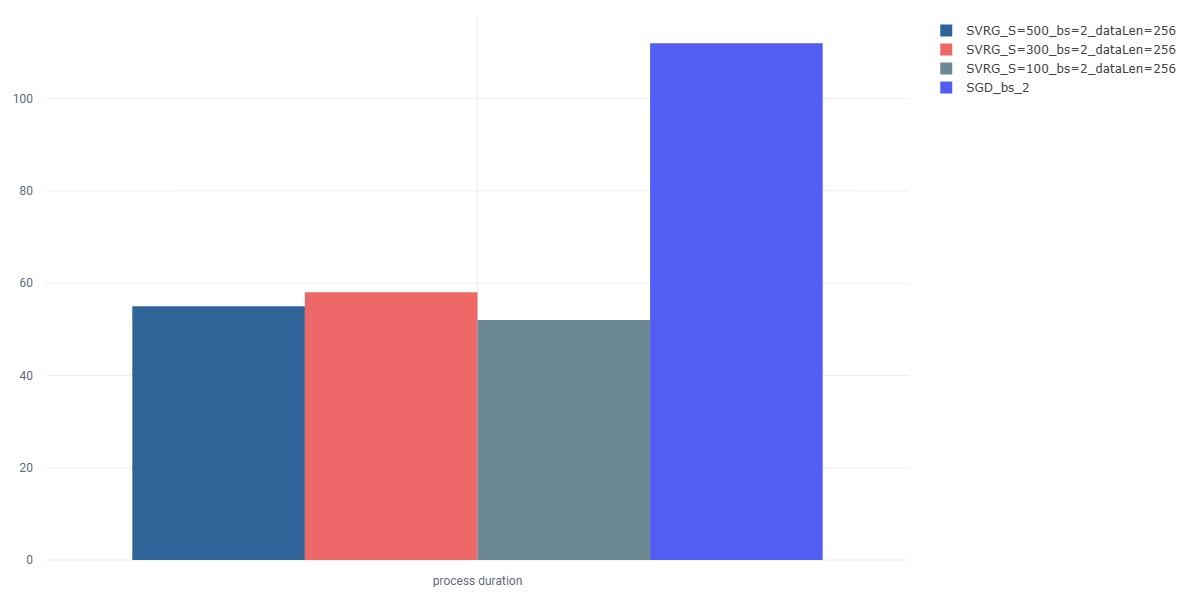

Accuracy и loss на валидации: 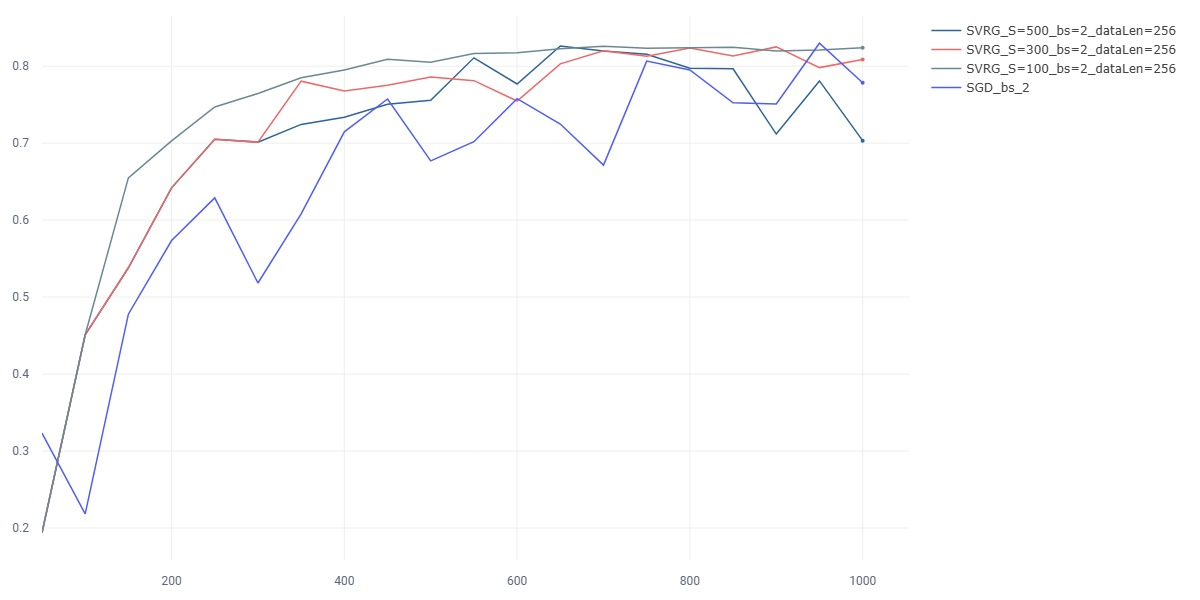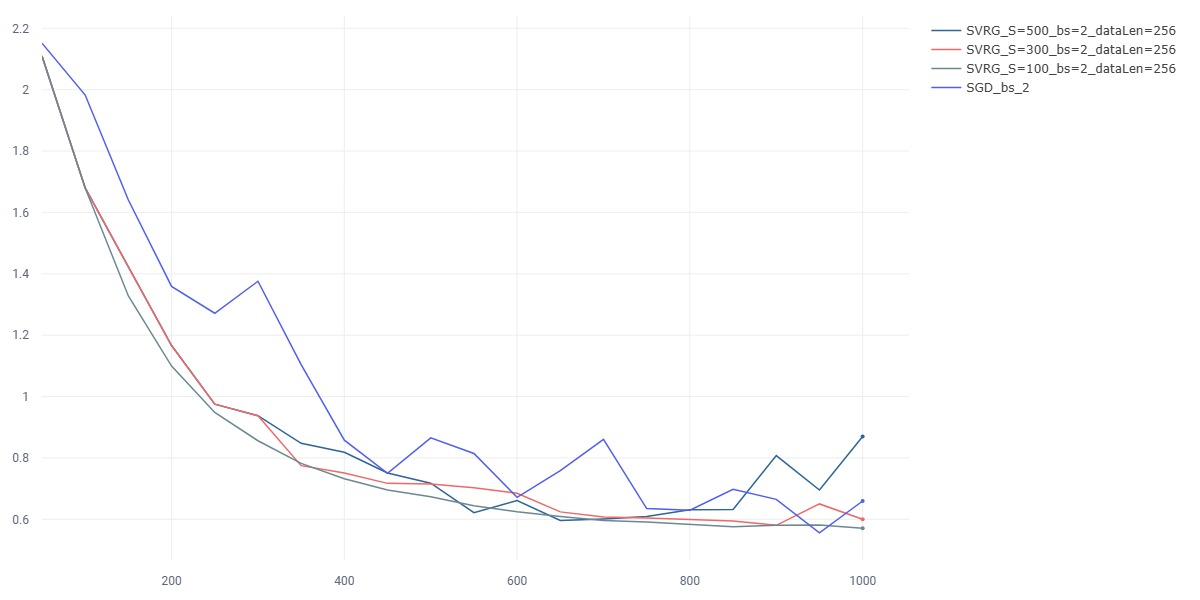

Дисперсия градиента: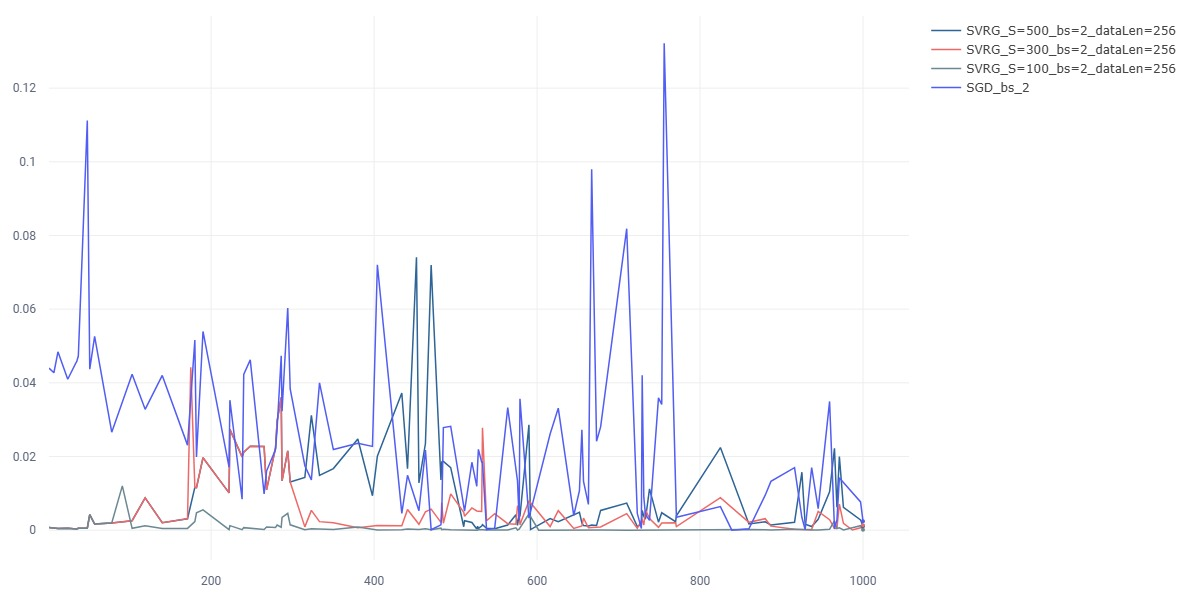

Accuracy и loss на обучающем датасете:
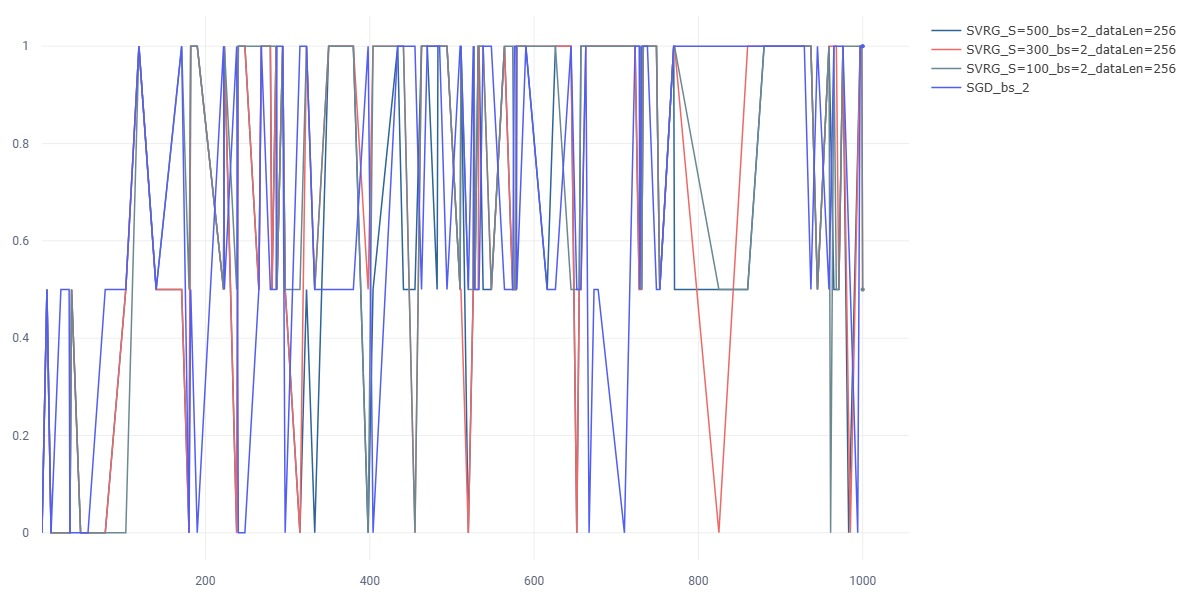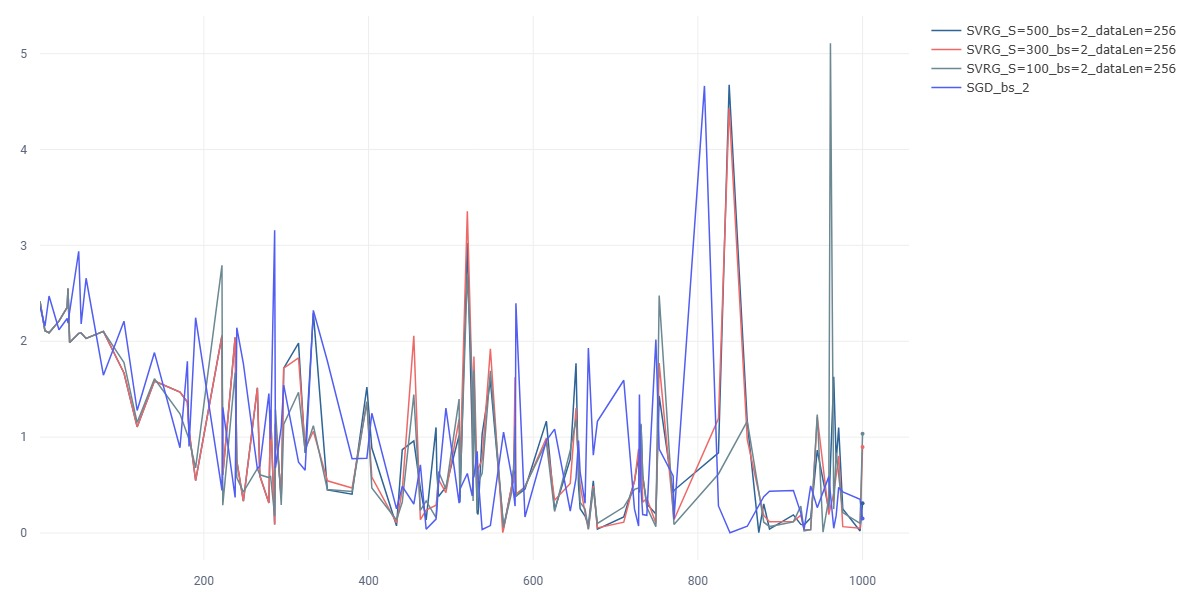

**Вывод 1**: на графиках сверху отображены три запуска с длиной data = 256 и различными S в сравнении с SGD с batch_size = 2 (все запуск SVRG делались с batch_size = 2). По графикам видно, что при фиксированной len_data с ростом S падает точность на валидации и соответственно растет loss. Обучение в целом становится менее стабильным, постоянные пики у loss'а и прыгающая точность на обучении видны на двух последних графиках. Все это является следствием более высокой дисперсии градиента, что видно на среднем графике. При этом время обучения при всех S примерно одинаковое и раза в два меньше, чем у SGD. Среднее количество подсчетов градиентов при S = 100, 300, 500 соответственно: 6.56, 4.85 и 4.512

**Теперь оценим, как влияет размер "большого" датасета len_data**

Accuracy и loss на трейне:
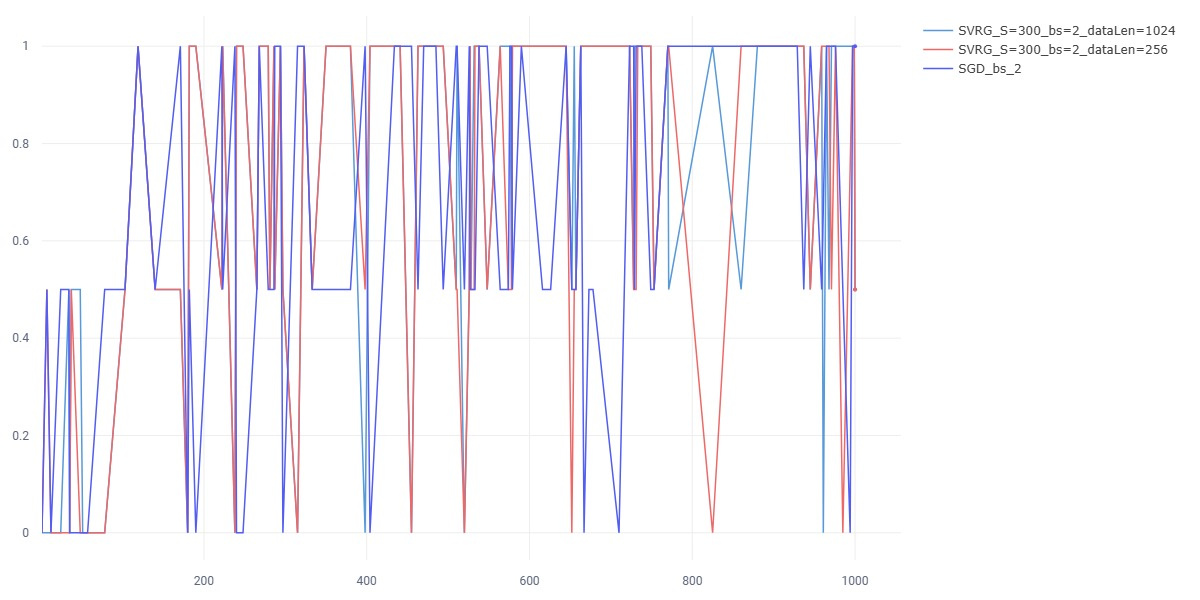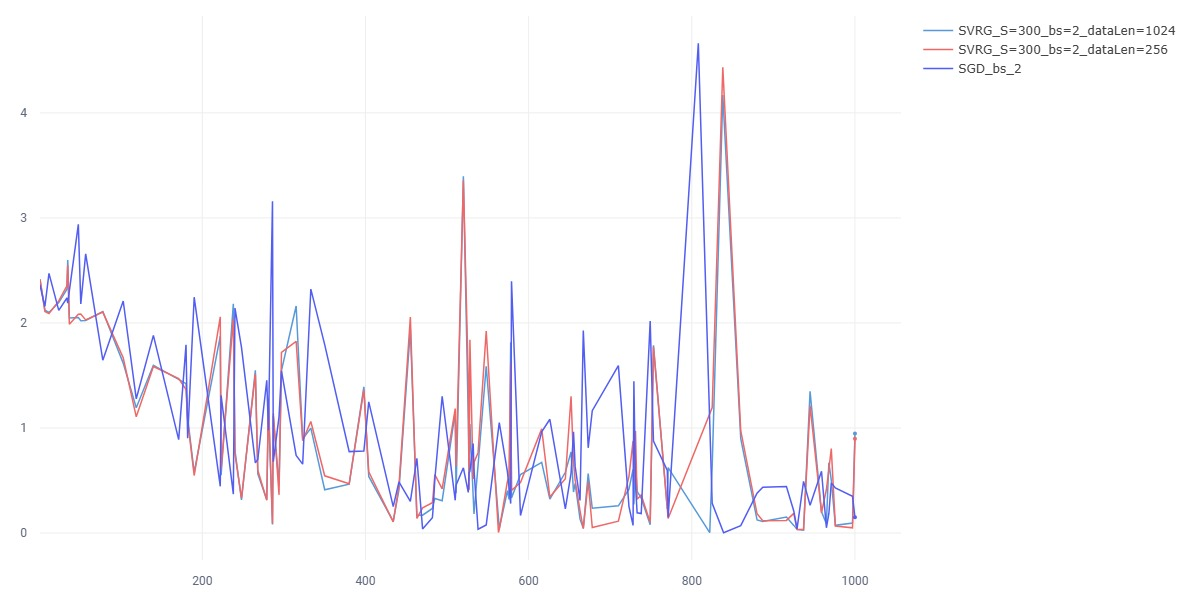

Время обучения:
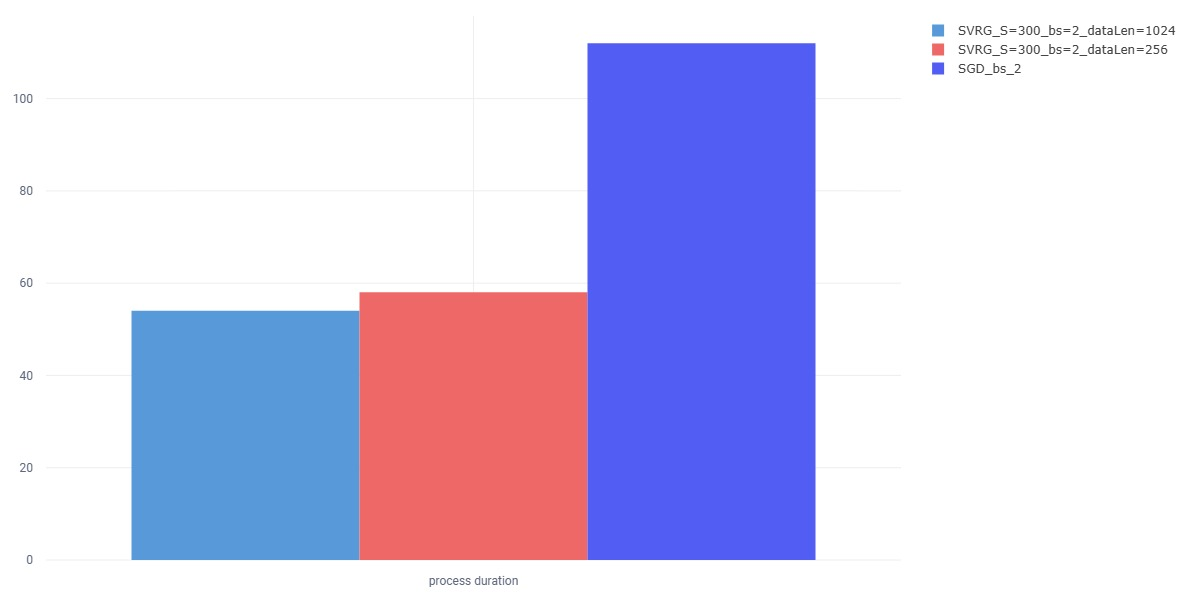

Дисперсия градиентов:

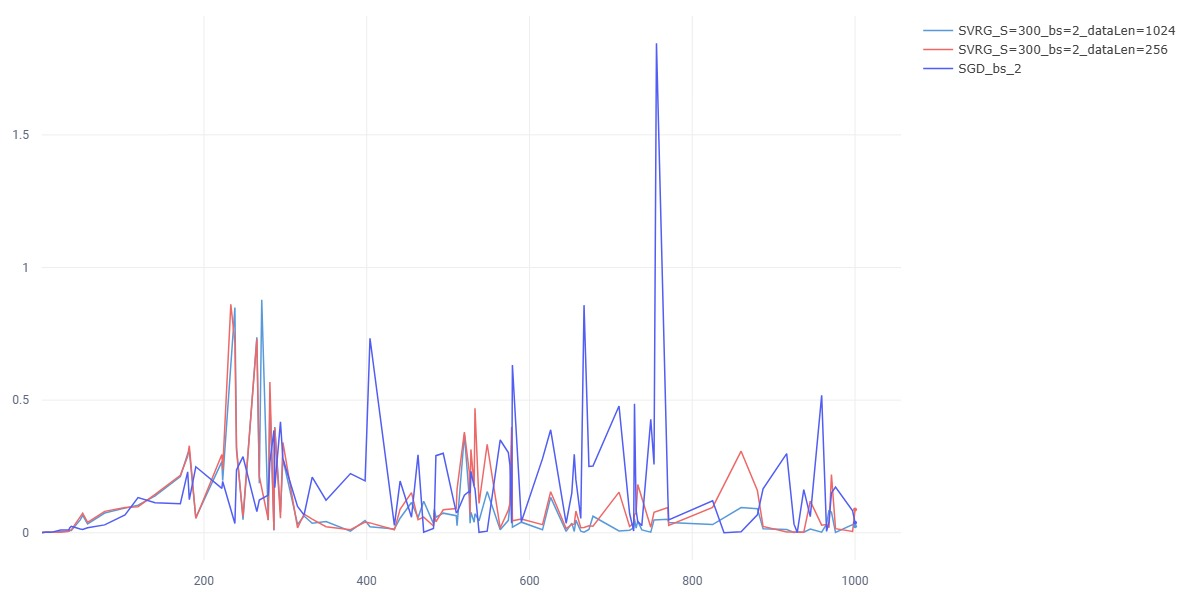

Accuracy и loss на валидации:

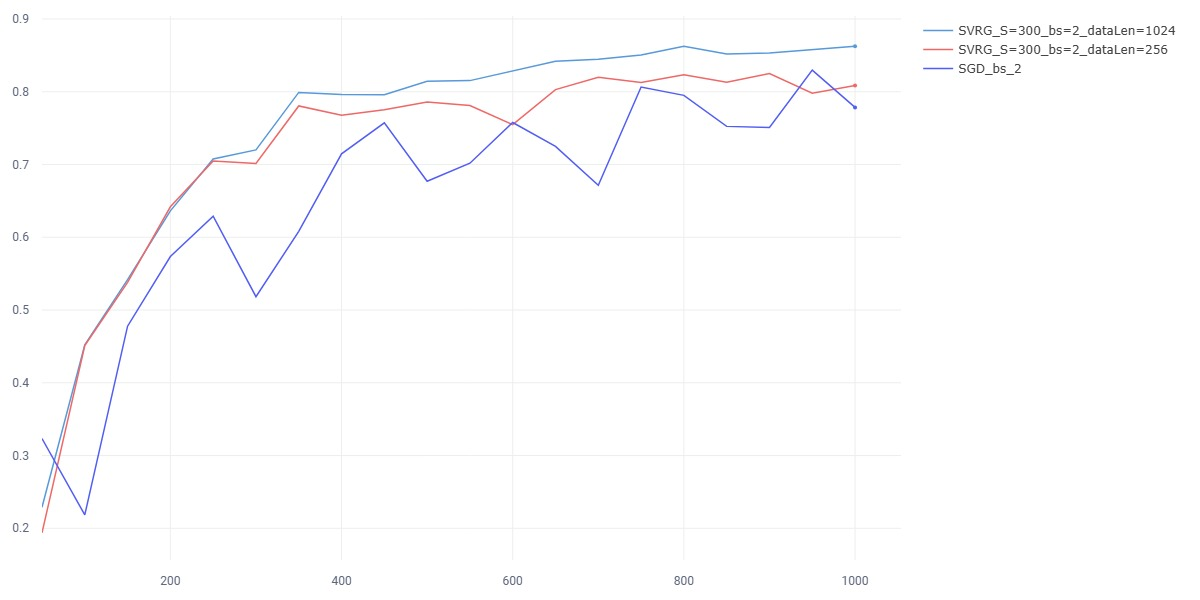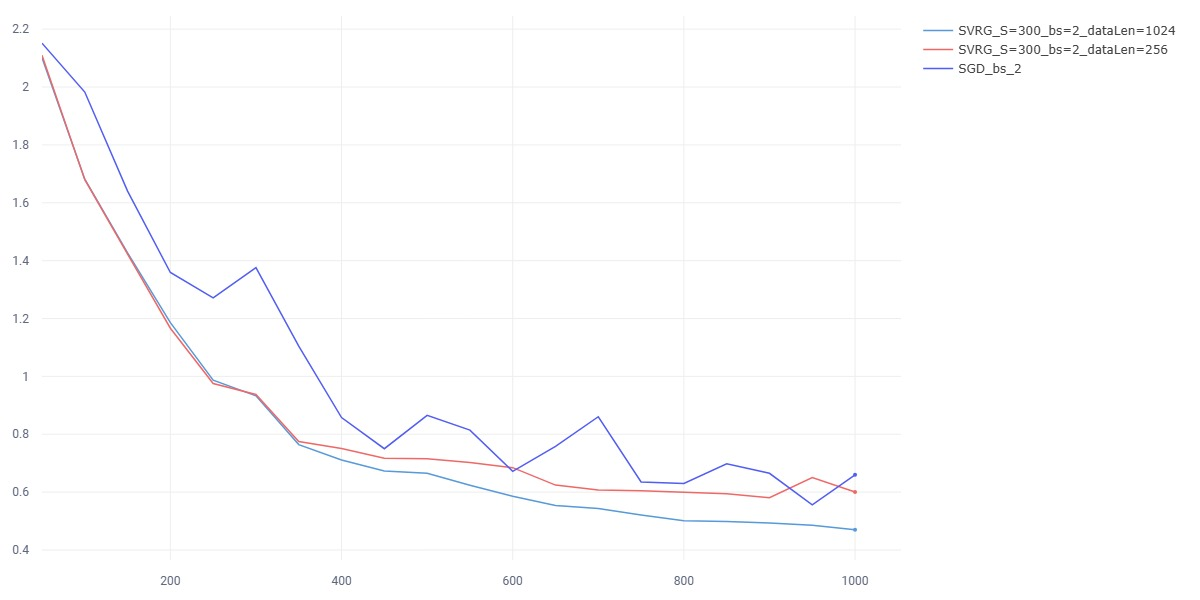

**Вывод 2**: на графиках сверху отображены два запуска с S = 300 и различной длиной data: 256 и 1024 в сравнении с SGD с batch_size = 2 (все запуск SVRG делались с batch_size = 2). По графикам видно, что при фиксированным S с ростом data_len растет точность на валидации и соответственно падает loss. При этом надо отметить, что дисперсия градиентов в случае с len_data = 1024 не сильно меньше, особенно на первых итерациях. А время обучения с len_data = 256 оказалось больше, при том что среднее число вычислений градиентов в данном случае больше у варианта с len_data = 1024: 7.41 против 4.85. В среднем, более "выгодный" для нас в смысле точности вариант меньше "прыгал" на трейне, показывав более гладкую кривую обучения, как впрочем и на валидации

**Бонус 1 (1 баллов)**: Уменьшить максимальное потребление видео памяти (обратить на внимание подсчета большого батча). Продемонстрировать как поменялось время обучение и потребление памяти.

**Бонус 2 (1.25 баллов)**: Проверить для других оптимизаторов влияние SVRG. При нашей реализации достаточно заменить базовый оптимизатор, на любой другой при создании обёртки. Сравнить сходимость метода и основные показатели

**Бонус 3 (1.25 баллов)**: Реализовать L-SVRG и сравнить результаты с SVRG и простым стохастическим градиентным спуском. Сравнить сходимость метода и основные показатели

**Бонус 4 (1.5 баллов)**: Реализовать метод [SAGA](https://www.di.ens.fr/~fbach/Defazio_NIPS2014.pdf) или любой другой метод понижения дисперсии (кроме батчирования). Описать идею метода. Сравнить сходимость метода и основные показатели

### Часть 4 (2.55 баллов). Методы Ньютона и LBFGS для пуассоновской регрессии.

В этой части задания вам предстоит обучить модель пуассоновской регрессии. Для этой задачи вы реализуете метод Ньютона и оракулы для Newton-CG и LBFGS.

###### Постановка задачи

Рассмотрим задачу количественной регрессии (count regression). Пусть дана выборка $\{x_i,y_i\}_{i=1}^\ell$, где $x_i\in\mathbb{R}^d$, $y_i\in\mathbb{N}\cup\{0\}$.

Будем считать, что
$$
y\sim p(y\,|\,\lambda)={e^{-\lambda}\over y!}\lambda^{y},
$$
где $\lambda=\exp(w^Tx)$.

Как вы могли догадаться, мы имеем дело с обобщённой линейной моделью. Обучение производится методом максимизации правдоподобия:
$$
p(X\,|\,w)=\prod_{i=1}^\ell p(y_i\,|\,x_i,w)\to\max_w\iff \mathcal{L}(x,y,w)=-\log p(y\,|\,\exp(w^Tx)),\ Q=\sum_{i=1}^\ell\mathcal{L}(x_i,y_i,w)\to\min_w.
$$

Алгоритм предсказания пуассоновской регрессии:
$$
a(x)=\lfloor\exp(w^Tx)\rfloor.
$$

**Задание 1. (0.5 баллов)**. Выведите формулы градиента $\nabla_wQ$ и гессиана $\nabla^2_wQ$.

**Решение:**

После подстановки всего и вся: $Q(w) = \sum_{i=1}^l (\exp(w^T x_i) - y_i w^T x_i + \log y_i!)$

$\nabla_w \exp(w^T x_i) = \exp(w^T x_i) x_i$

$\nabla_w y_i w^T x_i = y_i x_i$

$\nabla_w Q = \sum_{i=1}^l (\exp(w^T x_i) - y_i)x_i = \sum_{i=1}^l (\lambda_i - y_i)x_i$

$\nabla_w^2 Q = \sum_{i=1}^l \exp(w^T x_i) x_i^2$

**Задание 2 (0.8 баллов)**. Реализуйте полученные формулы в виде функции оракула.

In [ ]:
class Oracle:
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def fun(self, weights):
        """Compute objective, gradient, hessian"""
        z = self.X @ weights
        lam = np.exp(z)
        return np.sum(lam - self.y * z)

    def jac(self, weights):
        """Compute gradient. Use it for LBFGS, Newton-CG, Newton."""
        z = self.X @ weights
        lam = np.exp(z)
        return self.X.T @ (lam - self.y)

    def hess(self, weights):
        """Compute hessian. Use it for Newton."""
        z = self.X @ weights
        lam = np.exp(z)
        return self.X.T @ (lam[:, None] * self.X)

    def hessp(self, weights, vector):
        """Compute `hessian-times-vector` product. Use it for Newton-CG"""
        z = self.X @ weights
        lam = np.exp(z)
        Xv = self.X @ vector
        return self.X.T @ (lam * Xv)

In [ ]:
# Вспомогатейльный класс, который будет логгировать процесс обучения
from time import perf_counter


class Logger:
    def __init__(self):
        self.w = []
        self.time = []

    def __call__(self, weights):
        self.w.append(weights)

        if hasattr(self, 'prev'):
            self.time.append(perf_counter() - self.prev)

        self.prev = perf_counter()

**Задание 3. (0 баллов)**. Протестируем алгоритм на синтетических данных

In [ ]:
def cartesian_product(*arrays):
    """https://stackoverflow.com/a/11146645"""
    la = len(arrays)
    dtype = np.result_type(*arrays)
    arr = np.empty([len(a) for a in arrays] + [la], dtype=dtype)
    for i, a in enumerate(np.ix_(*arrays)):
        arr[...,i] = a
    return arr.reshape(-1, la)

Датасет будет состоять из точек, взятых по сетке на прямоугольнике [0,3] x [0,3]

In [ ]:
n_points_root = 50

x = np.linspace(0, 3, n_points_root)
y = np.linspace(0, 3, n_points_root)

features = cartesian_product(x, y)
features.shape

(2500, 2)

Зафиксируем золотое значение параметров:

In [ ]:
w = np.array([0.7, -0.25])

Метки сгенерируем из пуассоновского распределения:

In [ ]:
targets = np.random.poisson(np.exp(features @ w))
targets.shape

(2500,)

Визуализируем выборку:

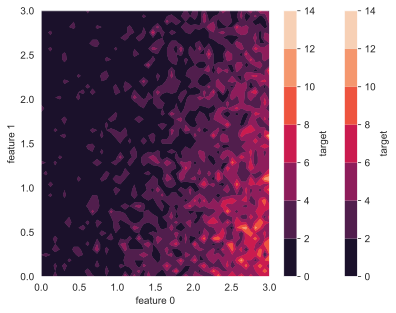

In [ ]:
import matplotlib.pyplot as plt

def visualise(z):
    ax = plt.contourf(x, y, z.reshape(n_points_root, n_points_root).T)
    cbar = plt.colorbar(ax)
    cbar.ax.set_ylabel('target')
    plt.xlabel('feature 0')
    plt.ylabel('feature 1')
    plt.show()

visualise(targets)

Следующая ячейка должна выполняться без ошибок **(иначе -0.4 балла)**

In [ ]:
from scipy.optimize import minimize

oracle = Oracle(features, targets)
cb = Logger()
weights = np.random.normal(size=2)
res = minimize(
    oracle.fun, weights,
    method="L-BFGS-B",
    jac=oracle.jac,
    callback=cb
)
res

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -400.20796684778065
        x: [ 6.864e-01 -2.321e-01]
      nit: 9
      jac: [-9.138e-07 -1.681e-06]
     nfev: 12
     njev: 12
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

Результат `res` должен содержать информацию об успешной оптимизации, а полученные веса должны быть похожи на те, что заданы выше:

In [ ]:
res['x']

array([ 0.68640021, -0.23211641])

Визуализируйте предсказания:

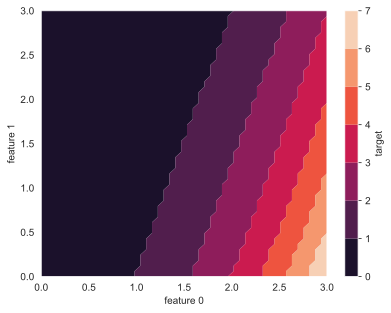

In [ ]:
pred = np.floor(np.exp(features @ res['x']))

visualise(pred)

Следующая ячейка должна выполняться без ошибок и сообщать об успешной оптимизации **(иначе -0.4 балла)**:

In [ ]:
oracle = Oracle(features, targets)
cb = Logger()
weights = np.random.normal(size=2)
res = minimize(
    oracle.fun, weights,
    method="Newton-CG",
    jac=oracle.jac,
    hessp=oracle.hessp,
    callback=cb,
)
res

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: -400.2079667508367
       x: [ 6.864e-01 -2.321e-01]
     nit: 7
     jac: [ 1.186e-01  1.196e-01]
    nfev: 8
    njev: 8
    nhev: 9

In [ ]:
res['x']

array([ 0.68639636, -0.23211098])

**Задание 4 (0.25 баллов)**. Реализуйте бектрекинг по правилу Армихо.

In [ ]:
def line_search(f, grad, x, d, c=1e-4, rho=0.9, tol=1e-3, alpha0=1):
    """
    Line search for learning rate with Armijo condition.

    Params
    ------
    f: objective function
    grad: vector
    x: current solution of optimization problem
    d: direction along which to search
    alpha0: initialization for alpha

    Return
    ------
    alpha: lr for newton step
    """
    alpha = alpha0
    znach = f(x)
    while f(x + alpha*d) > znach + c*alpha* (grad.T @ d):
        alpha = rho*alpha
        if alpha < tol:
            return alpha
    return alpha

**Задание 5. (0.25 баллов)**. Реализуйте демпфированный метод Ньютона. В качестве критерия останова используйте норму градиента (гиперпараметр `tol`).

*Замечание.* callback вызывать в конце каждой итерации.

In [ ]:
from scipy.optimize import OptimizeResult


def Newton(fun, x0, *args, **kwargs) -> OptimizeResult:
    # helper functions
    callback = kwargs['callback']
    jac = kwargs['jac']
    hess = kwargs['hess']

    # hyper params
    max_iter = kwargs['max_iter']
    tol = kwargs['tol']
    alpha0 = kwargs['alpha0']

    x = x0
    n_it = 0
    for t in range(1, max_iter+1):
        n_it = t
        grad = jac(x)
        g_norm = np.linalg.norm(grad)
        if g_norm <= tol:
            success = True
            break
        hessian = hess(x)
        p = np.linalg.solve(hessian, -grad)
        alpha = line_search(f=fun, grad=grad, x=x, d=p, alpha0=alpha0)
        x = x + alpha*p
        callback(x)
    loss = fun(x)
    return OptimizeResult(
        fun = loss,                 # resulting loss value
        x = x,                      # optimal weights
        n_it = n_it,                   # number of iterations used
        success = (n_it != max_iter)   # flag of success
    )

Следующая ячейка должна выполняться без ошибок и сообщать об успешной оптимизации

In [ ]:
oracle = Oracle(features, targets)
cb = Logger()
weights = np.random.normal(size=2)
res = minimize(
    oracle.fun, weights,
    method=Newton,
    jac=oracle.jac,
    hess=oracle.hess,
    callback=cb,
    options=dict(
        tol=0.1,
        max_iter=10,
        alpha0=1
    )
)
res

 success: True
     fun: -400.2079668098354
       x: [ 6.864e-01 -2.321e-01]
    n_it: 9

**Задание 6 (0.75 баллов)**. Применим методы к реальным данным

Применим наши три алгоритма к реальным данным. Источник данных: https://www.kaggle.com/datasets/pablomonleon/montreal-bike-lanes.

Описание к датасету:
> Is there a relationship between the number of bicyclists who use different bike paths on the same day? Can you predict how many riders there will be on one path given how many are on another?

In [ ]:
import pandas as pd

df = pd.read_csv('dataset.csv')

target = df['target']
features = df.drop(columns=['target'])
print(features.shape, target.shape)
features.head()

(319, 18) (319,)


,lane_0,lane_1,lane_2,lane_3,lane_4,lane_5,lane_6,lane_7,lane_8,lane_9,lane_10,lane_11,lane_12,lane_13,lane_14,lane_15,month,day
0,12,4,17,49,21,16,16,7,58,91,24,3,17,78,21,6,1,1
1,7,5,15,113,27,9,32,11,109,177,32,13,11,57,77,4,2,1
2,7,3,7,107,36,12,18,2,71,131,33,5,14,174,40,5,3,1
3,1,21,0,35,29,1,0,0,6,11,6,1,1,20,6,0,4,1
4,0,2,0,90,21,1,1,6,0,5,49,20,0,41,56,10,5,1


Следующая ячейка кодирует временные признаки и нормирует все остальные:

In [ ]:
# cycle encode time features
data = features[['month', 'day']].copy()
data['month_sin'] = np.sin(2 * np.pi * data['month']/31)
data['month_cos'] = np.cos(2 * np.pi * data['month']/31)

data['day_sin'] = np.sin(2 * np.pi * data['day']/12)
data['day_cos'] = np.cos(2 * np.pi * data['day']/12)

# normalize other features
data2 = features.drop(columns=['month', 'day'])
data2 = (data2 - data2.mean()) / data2.std()

# add constant feature
n_samples = df.shape[0]
features = pd.concat([data2, data[['month_sin', 'month_cos', 'day_sin', 'day_cos']]], axis=1)
features['constant'] = np.ones(n_samples)
features.head()

,lane_0,lane_1,lane_2,lane_3,lane_4,lane_5,lane_6,lane_7,lane_8,lane_9,...,lane_11,lane_12,lane_13,lane_14,lane_15,month_sin,month_cos,day_sin,day_cos,constant
0,-1.200839,-1.221582,-1.198296,-0.880348,-1.079269,-1.131425,-1.228446,-0.930486,-1.294226,-1.352611,...,-0.885145,-1.279551,-1.326210,-1.226873,-1.162284,0.201299,0.979530,0.5,0.866025,1.0
1,-1.203568,-1.221154,-1.200379,-0.854252,-1.072729,-1.138488,-1.217139,-0.927173,-1.263520,-1.311771,...,-0.841856,-1.285154,-1.341468,-1.192567,-1.170318,0.394356,0.918958,0.5,0.866025,1.0
2,-1.203568,-1.222010,-1.208713,-0.856698,-1.062920,-1.135461,-1.227033,-0.934626,-1.286399,-1.333616,...,-0.876487,-1.282353,-1.256462,-1.215233,-1.166301,0.571268,0.820763,0.5,0.866025,1.0
3,-1.206841,-1.214309,-1.216004,-0.886056,-1.070549,-1.146560,-1.239754,-0.936282,-1.325534,-1.390602,...,-0.893802,-1.294493,-1.368350,-1.236062,-1.186386,0.724793,0.688967,0.5,0.866025,1.0
4,-1.207387,-1.222437,-1.216004,-0.863630,-1.079269,-1.146560,-1.239047,-0.931314,-1.329146,-1.393451,...,-0.811554,-1.295427,-1.353092,-1.205432,-1.146217,0.848644,0.528964,0.5,0.866025,1.0


In [ ]:
X = features.to_numpy()
y = target.to_numpy()

X.shape, y.shape

((319, 21), (319,))

Разделите выборку случайно на трейн и тест в отношении 9:1, зафиксируйте `seed=0`. Обучите следующие алгоритмы и измерьте качество на отложенной выборке:

- LBFGS
- Newton-CG
- Newton
- `sklearn.linear_model.PoissonRegressor`

**Замечание.** Если для метода Ньютона раз в несколько запусков появляется ошибка `singular matrix`, то ничего страшного (наверное). Если метод часто расходится, то попробуйте поварьировать параметр `alpha0` или другие параметры бектрекинга.

**Подсказка.** Меряйте качество на отложенной выборке так: `np.mean((np.log(pred + 1) - np.log(y + 1)) ** 2)`.

**(!)** Для каждого алгоритма постройте scatterplot для пар (true, pred) на трейне и на тесте, который покажет, как плохи/хороши полученные предсказания.

**(!)** Сделайте выводы о полученных результатах. Насколько они согласуются с вашими ожиданиями?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor
from scipy.optimize import minimize

def scatter_true_pred(y_true, y_pred, title):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=8, alpha=0.5)
    m = max(float(np.max(y_true)), float(np.max(y_pred)))
    plt.plot([0, m], [0, m])
    plt.xlabel("true")
    plt.ylabel("pred")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def poisson_metric(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_pred = np.maximum(y_pred, 0.0)
    return np.mean((np.log(y_pred + 1.0) - np.log(y_true + 1.0)) ** 2)

def predict_lambda(X, w):
    return np.exp(X @ w)

L-BFGS-B: success = True | n_it = 120
  metric train: 0.47284041194018234
  metric test : 0.5224217191785773


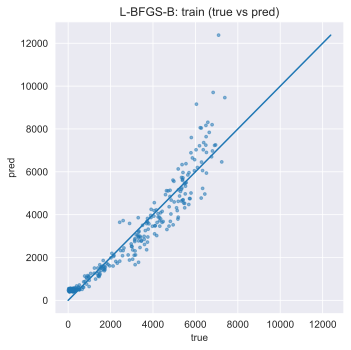

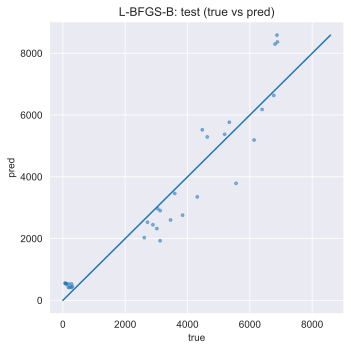

Newton-CG: success = True | n_it = 24
  metric train: 0.472479847543445
  metric test : 0.5220473629425162


C:\Users\Home\AppData\Local\Temp\ipykernel_9172\3163893479.py:9: RuntimeWarning: overflow encountered in exp
  lam = np.exp(z)
C:\Users\Home\AppData\Local\Temp\ipykernel_9172\3163893479.py:15: RuntimeWarning: overflow encountered in exp
  lam = np.exp(z)
C:\Users\Home\AppData\Local\Temp\ipykernel_9172\3163893479.py:16: RuntimeWarning: invalid value encountered in matmul
  return self.X.T @ (lam - self.y)
C:\Users\Home\AppData\Local\Temp\ipykernel_9172\3163893479.py:9: RuntimeWarning: overflow encountered in exp
  lam = np.exp(z)


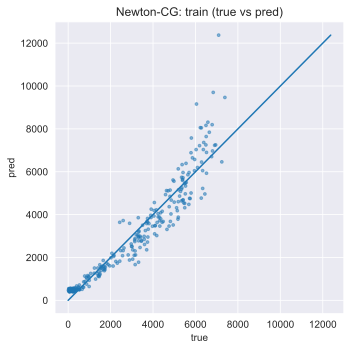

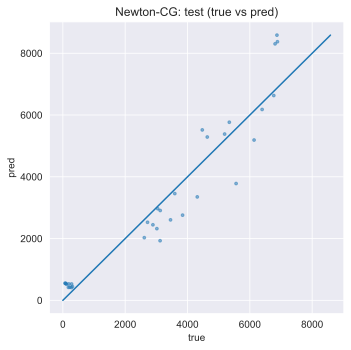

Newton (damped): success = True | n_it = 9
  metric train: 0.4724821010067581
  metric test : 0.5220502771830859


C:\Users\Home\AppData\Local\Temp\ipykernel_9172\3163893479.py:9: RuntimeWarning: overflow encountered in exp
  lam = np.exp(z)


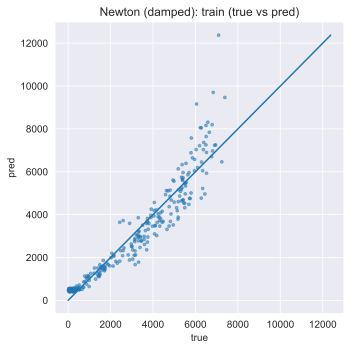

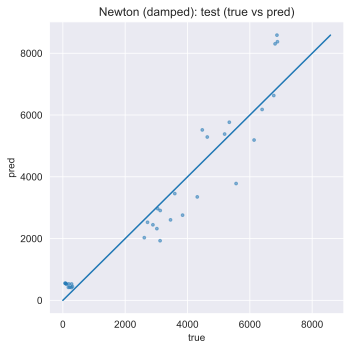

sklearn PoissonRegressor
  metric train: 0.4724812270349086
  metric test : 0.522049768590616
  coef_: [-6.19720183e-01  1.50839336e+00  4.14376215e-02  4.41192940e-02
  5.30363071e-03 -2.95955684e-01  1.21125679e-01  2.55723616e-02
 -2.58901468e-01  9.13588192e-01 -5.54379627e-01 -6.20270747e-02
 -9.73558912e-03  8.82711238e-02 -3.72938058e-02  2.31025073e-02
  2.40895233e-01 -9.84430250e-02 -5.27025136e-02 -2.03563227e-03
  7.39802870e+00]
  intercept_: 0.0


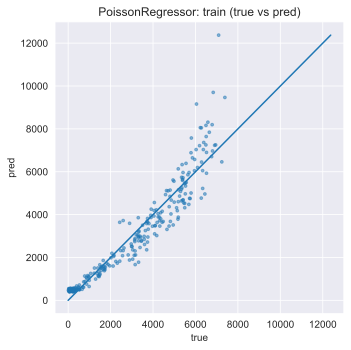

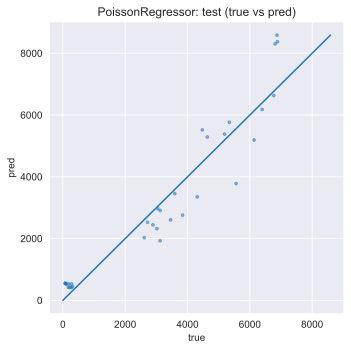

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0, shuffle=True)

d = X_train.shape[1]
w0 = np.zeros(d)

oracle = Oracle(X_train, y_train)
cb_lbfgs = Logger()

res_lbfgsb = minimize(
    oracle.fun, w0,
    method="L-BFGS-B",
    jac=oracle.jac,
    callback=cb_lbfgs
)

w_lbfgs = res_lbfgsb.x
pred_train = predict_lambda(X_train, w_lbfgs)
pred_test  = predict_lambda(X_test,  w_lbfgs)

print("L-BFGS-B:", "success =", res_lbfgsb.success, "| n_it =", getattr(res_lbfgsb, "nit", None))
print("  metric train:", poisson_metric(y_train, pred_train))
print("  metric test :", poisson_metric(y_test,  pred_test))

scatter_true_pred(y_train, pred_train, "L-BFGS-B: train (true vs pred)")
scatter_true_pred(y_test,  pred_test,  "L-BFGS-B: test (true vs pred)")

oracle = Oracle(X_train, y_train)
cb_newtoncg = Logger()

res_newtoncg = minimize(
    oracle.fun, w0,
    method="Newton-CG",
    jac=oracle.jac,
    hessp=oracle.hessp,
    callback=cb_newtoncg
)

w_newtoncg = res_newtoncg.x
pred_train = predict_lambda(X_train, w_newtoncg)
pred_test  = predict_lambda(X_test,  w_newtoncg)

print("Newton-CG:", "success =", res_newtoncg.success, "| n_it =", getattr(res_newtoncg, "nit", None))
print("  metric train:", poisson_metric(y_train, pred_train))
print("  metric test :", poisson_metric(y_test,  pred_test))

scatter_true_pred(y_train, pred_train, "Newton-CG: train (true vs pred)")
scatter_true_pred(y_test,  pred_test,  "Newton-CG: test (true vs pred)")

oracle = Oracle(X_train, y_train)
cb_newton = Logger()

res_newton = minimize(
    oracle.fun, w0,
    method=Newton,
    jac=oracle.jac,
    hess=oracle.hess,
    callback=cb_newton,
    options=dict(
        tol=0.1,
        max_iter=10,
        alpha0=1
    )
)

w_newton = res_newton.x
pred_train = predict_lambda(X_train, w_newton)
pred_test  = predict_lambda(X_test,  w_newton)

print("Newton (damped):", "success =", res_newton.success, "| n_it =", getattr(res_newton, "n_it", None))
print("  metric train:", poisson_metric(y_train, pred_train))
print("  metric test :", poisson_metric(y_test,  pred_test))

scatter_true_pred(y_train, pred_train, "Newton (damped): train (true vs pred)")
scatter_true_pred(y_test,  pred_test,  "Newton (damped): test (true vs pred)")

pr = PoissonRegressor(alpha=0.0, max_iter=1000, tol=1e-8, fit_intercept=False)
pr.fit(X_train, y_train)

pred_train = pr.predict(X_train)
pred_test  = pr.predict(X_test)

print("sklearn PoissonRegressor")
print("  metric train:", poisson_metric(y_train, pred_train))
print("  metric test :", poisson_metric(y_test,  pred_test))
print("  coef_:", pr.coef_)
if hasattr(pr, "intercept_"):
    print("  intercept_:", pr.intercept_)

scatter_true_pred(y_train, pred_train, "PoissonRegressor: train (true vs pred)")
scatter_true_pred(y_test,  pred_test,  "PoissonRegressor: test (true vs pred)")

**Вывод**: все методы сошлись к одному и тому же решению, что в целом было ожидаемо ввиду несложной постановки задачи и выпуклой функции потерь. Ожидаемо, быстрее всех сошелся Newton за счет квадратичной сходимости, далее пошел Newton-CG, а L-BFGS-B сходился дольше всех (120 итераций). Значения метрик у разных методов тоже оказались примерно одинаковые (с точностью до сотых), а значит методы нашли один и тот же минимум. Переобучение в общем-то не сильно большое, так как зазор между трейном и тестом по метрике сравнительно небольшой. Наблюдаемое увеличение разброса предсказаний при больших значениях целевой переменной согласуется со свойством распределения Пуассона, где дисперсия равна математическому ожиданию

### Часть 5. (1.5 баллов) CVXPY

Для анализа изображений часто используется метод неотрицательной матричной факторизации ([Nonnegative matrix factorization](https://arxiv.org/pdf/1401.5226.pdf)).
Идея в том, чтобы решить следующую задачу

\begin{align*}
& \min_{W, H} \frac12 \|X - WH\|^2_F \\
\text{s.t. } & W \geq 0\\
& H \geq 0,
\end{align*}

где знак $\geq$ означает покомпонентное сравнение.
Также матрицы $W$ и $H$ малого ранга, то есть $W \in \mathbb{R}^{m \times k}$ и $H \in \mathbb{R}^{k \times n}$, где $k$ - параметр, который необходимо настраивать.
Чем больше $k$, тем точнее приближение, но и тем дольше будет решаться задача.
Матрица $X \in \mathbb{R}^{m \times n}$, где $m$ - это число фото в нашем наборе, а $n$ - это количество пикселей в каждой картинке, то есть каждая строка матрицы $X$ - это векторизованная картинка.

**Задание 0. (0.15 баллов)** Как можно интерпретировать факторы $W$ и $H$ и почему важна их покомпонентная не отрицательность?

**Ответ:** можно сказать (инфоцыганство), что строки матрицы H это какие-то паттерны, которые могут быть на изображении, а W - это коэффициенты того, что этот паттерн в каком-то виде/месте присутствует на изображении. Покомпонентная неотрицательность помогает нам сделать это разложение полность интерпретируемым и получать буквально сумму паттернов.

Такую задачу можно решать с помощью cvxpy, если воспользоваться идеей попеременной оптимизации (alternating optimization). Идея состоит в том, чтобы на чётных итерациях решить точно задачу относительно параметра $W$ при фиксированном параметре $H$, а на нечётных наоборот: использовать решение для $W$ с предыдущей итерации в качестве фиксированного параметра и найти решение задачи относительно $H$ и так далее до сходимости.
Сначала Вам нужно инициализировать матрицы $W$ и $H$ какими-нибудь матрицами с неотрицательными элементами.

Загрузим данные. Мы будем раскладывать изображения лиц. О таком подходе к анализу фотографий лиц вам рассказывали или расскажут в курсе ОиРИ, а тут вы просто реализуете этот метод

In [ ]:
!pip install cvxpy

Shape of data = (400, 64, 64)


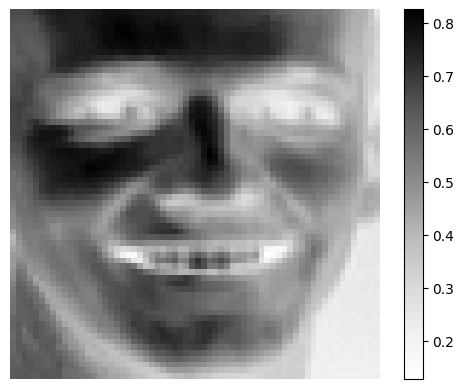

In [1]:
import cvxpy as cvx
import sklearn.datasets as skldata
import matplotlib.pyplot as plt
import sklearn.decomposition as skdec
%matplotlib inline
data = skldata.fetch_olivetti_faces()
import numpy as np
print("Shape of data = {}".format(data["images"].shape))
index = 42
plt.imshow(data["images"][index], cmap=plt.cm.Greys)
plt.colorbar()
_ = plt.axis("off")

**Задание 1. (1.05 балл)** Реализуйте с помощью cvxpy идею попеременной оптимизации для этой задачи и решите её

*Совет от Соника:* Сперва тестируйте алгоритм не на всех данных, так как вычисления занимают большое количество времени

*Замечание*: все еще можно менять интерфейсы функций

**Важное замечание.**

Если у вас уходит больше трех минут на итерацию, то скорее всего что-то идет не так. Алгоритм действий в таком случае:
1) Проверить, что стоит нормальный солвер (авторское решение на CLARABEL, его нужно поставить отдельно и перезапустить среду);
2) Не использовать Colab, так как там используются старые CPU, и вычисления на них могут быть слишком медленные;
3) Уменьшить размер данных;
4) Использовать ранг поменьше.

In [3]:
def non_negative_matrix_factorization(X, rank, max_iters, tol, log=False):
    """
    X - матрица изображений. Каждое изображение является строкой
    rank - какой будете использовать ранг
    max_iters - максимальное количество итераций
    tol - точность, с какой решается задача
    log - флаг, отвечающий за то, будете ли вы печатать логи или нет (такое желание может возникнуть, так как
    алгоритм будет работать долго)
    Функция возвращает найденные матрицы H и W, а также значения функционала в ходе оптимизации
    """
    m, n = X.shape
    k = rank
    np.random.seed(42)
    H = np.random.rand(k, n) * 0.1
    W = np.random.rand(m, k) * 0.1

    objective_values = []
    prev_obj = None

    for t in range(max_iters):
        if t % 2 == 0:
            W_val = cvx.Variable((m, k), nonneg=True)
            obj = cvx.Minimize(0.5*cvx.sum_squares(X - W_val @ H))
            prob = cvx.Problem(obj)
            prob.solve(solver=cvx.CLARABEL, verbose=log, ignore_dpp=True)
            if W_val.value is not None:
                W = W_val.value.copy()
        else:
            H_val = cvx.Variable((k, n), nonneg=True)
            obj = cvx.Minimize(0.5*cvx.sum_squares(X - W @ H_val))
            prob = cvx.Problem(obj)
            prob.solve(solver=cvx.CLARABEL, verbose=log, ignore_dpp=True)
            if H_val.value is not None:
                H = H_val.value.copy()

        cur_obj = 0.5*np.sum((X - W @ H)**2)
        objective_values.append(cur_obj)
        if prev_obj != None:
            if np.abs(cur_obj - prev_obj) < tol:
                break
        prev_obj = cur_obj
        if t % 5 == 0:
            print(f'Current obj: {cur_obj}')
    return H, W, objective_values

In [4]:
images = data.images
X = images.reshape(images.shape[0], -1)
eps = 1e-8
X = np.maximum(X, eps)
H_val, W_val, objective_values = non_negative_matrix_factorization(X, 25, 50, 1e-4, False)

Current obj: 23794.995424119246
Current obj: 4312.795448527632
Current obj: 3897.9076125307165
Current obj: 3750.63662192063
Current obj: 3673.5431149021824
Current obj: 3624.7444042348557
Current obj: 3591.5464447850304
Current obj: 3568.415611333985
Current obj: 3550.865564332507
Current obj: 3537.6424475990334


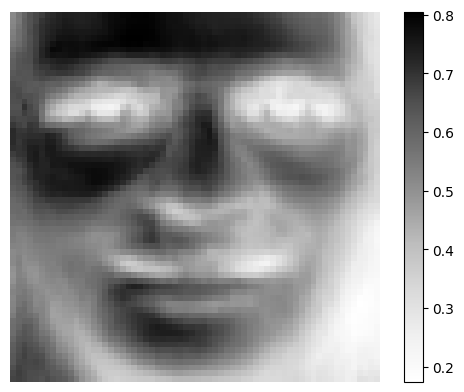

In [5]:
image = W_val @ H_val
plt.imshow(image[42].reshape(64, 64), cmap=plt.cm.Greys)
plt.colorbar()
_ = plt.axis("off")

**Задание 2. (0.1 балл)** Нарисуйте график сходимости по функции и убедитесь, что метод сошёлся или же изменение целевой функции пренебрежимо мало

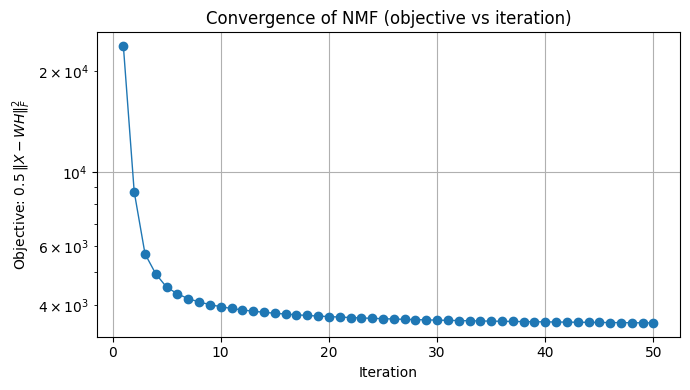

In [12]:
obj = np.asarray(objective_values, dtype=float)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(obj) + 1), obj, marker="o", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel(r"Objective: $0.5\,\|X - WH\|_F^2$")
plt.title("Convergence of NMF (objective vs iteration)")
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

**Задание 3. (0.1 баллов)** Поскольку размерность $H$ - $k \times n$, то каждую строку $H$ можно преобразовать в картинку аналогично тому, как были собраны строки матрицы $X$. Нарисуйте 10 картинок полученных из строк матрицы $H$. Что Вы заметили и как это соотносится с ответами на вопрос задания 0?

*Hint:* Используйте ```plt.colorbar()``` и цветовую схему ```plt.cm.Greys``` для более чёткого отображения значений пикселей

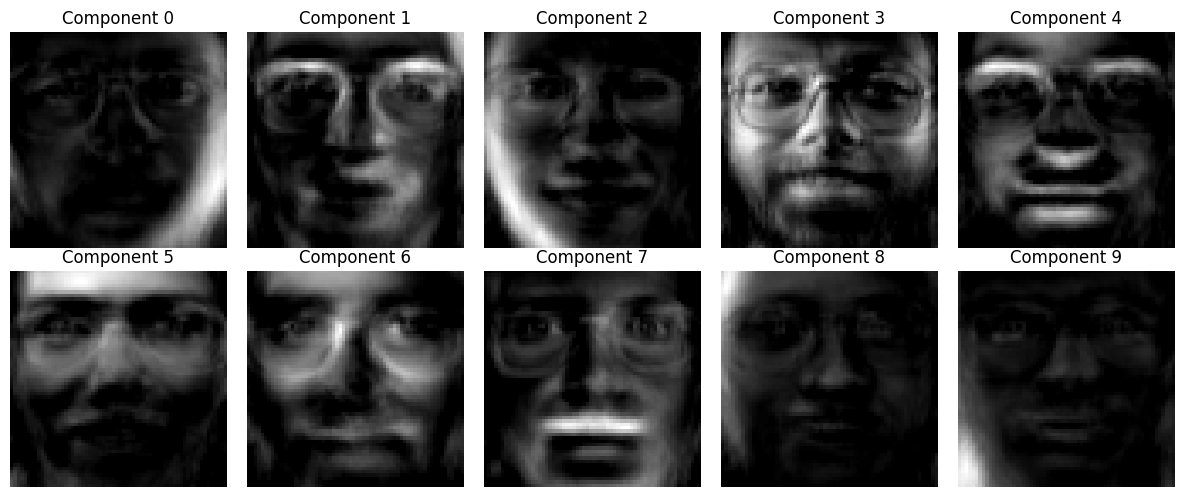

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(H_val[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Component {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Ответ**: подтвердилось мое предположение, что строки матрицы H это паттерны какие-то (в данном случае, это буквально целые лица, из которых потом собираются все остальные)

**Задание 4. (0.1 баллов)** Нарисуйте матрицу $W$ с помощью функции `plt.imshow` (или `plt.spy`). Насколько сильно она заполнена и почему?

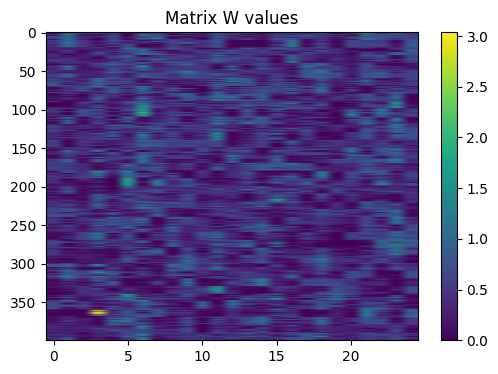

In [11]:
plt.figure(figsize=(6,4))
plt.imshow(W_val, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Matrix W values")
plt.show()

**Ответ**: матрица почти полностью заполнена, так как не было регуляризации на разреженность

### Бонус

**Задание. (0.7 баллов)** Пробудите в себе внутреннего мемодела и придумайте мемный шедевр на тему ваших взаимоотношений с методами оптимизации.

**Ваш мем:**
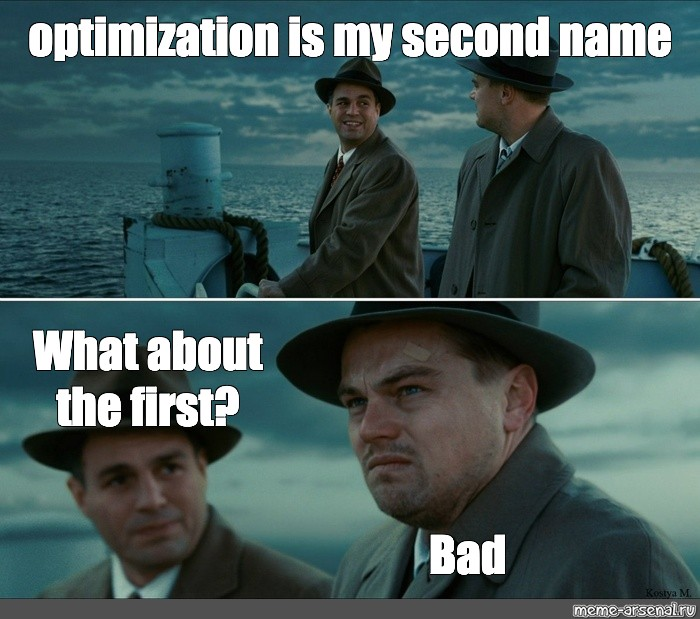